# CellChatPy Comparison Analysis of Multiple Datasets

**Corresponds to:** R tutorial `R-tutorial/Comparison_analysis_of_multiple_datasets.html`

**Data:** Human skin scRNA-seq - **NL** (Non-Lesional) vs **LS** (Lesional)

**Data source:** `data/data_humanSkin.h5` (contains both conditions).

This notebook uses the current `CellChatPy` package and canonical CellChatPy data structure. It creates one object for each condition, infers their communication networks, and compares the two datasets.

**Outline:**
- Load, split, and preprocess the two datasets
- **Part I** - Identify altered interactions and cell populations
- **Part II** - Identify signaling with distinct network architecture
- **Part III** - Identify up- and down-regulated signaling L-R pairs
- **Part IV** - Compare communication using circle, heatmap, and chord plots
- **Part V** - Compare signaling gene expression between datasets

## Setup and Imports

In [1]:
import copy
import os
import pickle
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Resolve the repository from either the project root or the tutorial folder.
project_root = (
    Path(os.getcwd()).resolve().parent
    if Path(os.getcwd()).name == "tutorial"
    else Path(os.getcwd()).resolve()
)
if (project_root / "CellChatPy").is_dir() and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc
import CellChatPy.analysis as cc_analysis

%matplotlib inline

OUT_DIR = (project_root / "tutorial" / "figures_comparison").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None
    path = Path(OUT_DIR) / name
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc
    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)
    return None


print(f"Using CellChatPy from: {cc.__file__}")
print(f"Using CellChatPy analysis from: {cc_analysis.__file__}")
print(f"Figures will be saved to: {OUT_DIR}")
ptm_total = time.time()

Using CellChatPy from: E:\Jin\cellchat.python_new\CellChatPy\__init__.py
Using CellChatPy analysis from: E:\Jin\cellchat.python_new\CellChatPy\analysis.py
Figures will be saved to: E:\Jin\cellchat.python_new\tutorial\figures_comparison


---
## Load Data and Split by Condition

The R tutorial starts from two saved CellChat objects. Here, both conditions are read from one HDF5 file and separated using the `condition` metadata column.

In [2]:
ptm = time.time()

data_path = project_root / "data" / "data_humanSkin.h5"
if not data_path.is_file():
    raise FileNotFoundError(f"Input HDF5 file not found: {data_path}")
print(f"Loading {data_path} ...")


def _decode_values(values):
    return [value.decode() if isinstance(value, bytes) else str(value) for value in values]


with h5py.File(data_path, "r") as f:
    dim = f["data/dim"][:]
    indices = f["data/indices"][:]
    indptr = f["data/indptr"][:]
    values = f["data/values"][:]
    genes = _decode_values(f["genes"][:])
    cells = _decode_values(f["cells"][:])
    condition = _decode_values(f["meta/condition"][:])
    labels = _decode_values(f["meta/labels"][:])
    rownames = _decode_values(f["meta/rownames"][:])
    patient = _decode_values(f["meta/patient.id"][:])

mat = sp.csc_matrix((values, indices, indptr), shape=(int(dim[0]), int(dim[1])))
meta_all = pd.DataFrame(
    {"patient.id": patient, "condition": condition, "labels": labels},
    index=rownames,
)

if cells != rownames:
    raise ValueError("HDF5 cells and metadata rownames are not aligned.")
if mat.shape != (len(genes), len(cells)):
    raise ValueError(
        f"HDF5 matrix shape {mat.shape} does not match "
        f"{len(genes)} genes x {len(cells)} cells."
    )

print(f"Expression matrix: {mat.shape[0]:,} genes x {mat.shape[1]:,} cells")
display(meta_all.head())
print(f"Load elapsed: {time.time() - ptm:.1f}s")

Loading E:\Jin\cellchat.python_new\data\data_humanSkin.h5 ...
Expression matrix: 17,328 genes x 7,563 cells


,patient.id,condition,labels
S1_AACTCCCAGAGCTGCA,Patient1,LS,Inflam. FIB
S1_CAACCAATCCTCATTA,Patient1,LS,FBN1+ FIB
S1_CGCTATCTCCTAGTGA,Patient1,LS,Inflam. FIB
S1_ATTTCTGCAGGACGTA,Patient1,LS,Inflam. FIB
S1_TGAGCCGAGCTGGAAC,Patient1,LS,Inflam. FIB


Load elapsed: 0.7s


In [3]:
r_cell_levels = [
    "APOE+ FIB", "FBN1+ FIB", "COL11A1+ FIB", "Inflam. FIB",
    "cDC1", "cDC2", "LC", "Inflam. DC",
    "TC", "Inflam. TC", "CD40LG+ TC", "NKT",
]
missing_levels = sorted(set(meta_all["labels"].dropna().unique()) - set(r_cell_levels))
if missing_levels:
    raise ValueError(f"Unexpected cell labels not present in R levels: {missing_levels}")

meta_all["cellchat_group"] = pd.Categorical(
    meta_all["labels"], categories=r_cell_levels, ordered=True
)


# CellChatPy expects cells x genes; the HDF5 expression matrix is genes x cells.
matrix_all = mat.T.tocsr()
cellchat_all = cc.create_cellchat(
    object=matrix_all, metadata=meta_all, group_by="cellchat_group",
    genes=genes, cells=cells,
)

cellchat_NL = cc.subset_cellchat(
    cellchat_all, metadata_filter={"condition": "NL"}
)
cellchat_LS = cc.subset_cellchat(
    cellchat_all, metadata_filter={"condition": "LS"}
)
print(f"NL: {cellchat_NL.n_obs:,} cells x {cellchat_NL.n_vars:,} genes")
print(f"LS: {cellchat_LS.n_obs:,} cells x {cellchat_LS.n_vars:,} genes")
print(f"Cell groups: {r_cell_levels}")

Create a CellChat object from a data matrix
Cell groups used for CellChat analysis: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
Cell groups used for analysis: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
Cell groups used for analysis: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
NL: 2,552 cells x 17,328 genes
LS: 5,011 cells x 17,328 genes
Cell groups: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']


---
## Create CellChat Objects and Set the Database

Create one CellChat object per condition and use the human `Secreted Signaling` interaction database, matching the R tutorial.

In [4]:
print("NL cell groups:", list(cellchat_NL.groups.categories))
print("LS cell groups:", list(cellchat_LS.groups.categories))

NL cell groups: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
LS cell groups: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']


In [5]:
cellchat_db = cc.load_database(species="human")
db_use = cc.subset_database(
    cellchat_db, search="Secreted Signaling", key="annotation"
)
cellchat_NL.database = copy.deepcopy(db_use)
cellchat_LS.database = copy.deepcopy(db_use)

print(f"Secreted Signaling interactions: {len(db_use['interaction']):,}")

Secreted Signaling interactions: 1,280


---
## Run the CellChat Pipeline for Each Condition

For each condition, identify over-expressed signaling genes and interactions, infer communication probabilities, aggregate ligand-receptor interactions into pathways, and compute pathway-level centrality.

In [6]:
object_list = {"NL": cellchat_NL, "LS": cellchat_LS}


def run_cellchat_pipeline(cellchat, name):
    print(f"Analyzing {name} ...")
    cellchat = cc.subset_signaling_data(cellchat)
    cellchat = cc.identify_overexpressed_genes(cellchat, do_fast=True)
    cellchat = cc.identify_overexpressed_interactions(cellchat)
    cellchat = cc.compute_communication_probability(
        cellchat, type_method="triMean"
    )
    cellchat = cc.filter_communication(cellchat, min_cells=10)
    cellchat = cc.compute_pathway_probability(cellchat)
    cellchat = cc.aggregate_network(cellchat)
    cellchat = cc.compute_network_centrality(
        cellchat, slot_name="pathway_network"
    )
    print(
        f"  Significant pathways: "
        f"{len(cellchat.pathway_network.get('prob', {}))}"
    )
    return cellchat


cellchat_NL = run_cellchat_pipeline(cellchat_NL, "NL")
cellchat_LS = run_cellchat_pipeline(cellchat_LS, "LS")
object_list = {"NL": cellchat_NL, "LS": cellchat_LS}

Analyzing NL ...
The number of highly variable ligand-receptor pairs used for signaling inference is 491
triMean is used for calculating the average gene expression per cell group.
Pre-computing 100 bootstrap averaged expressions...
Computing communication probabilities for 491 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Excluding cell groups due to few cells: ['cDC1', 'Inflam. DC']
Pathway-level results stored in .pathway_network.
  Significant pathways: 15
Analyzing LS ...
The number of highly variable ligand-receptor pairs used for signaling inference is 688
triMean is used for calculating the average gene expression per cell group.
Pre-computing 100 bootstrap averaged expressions...
Computing communication probabilities for 688 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Pathway-level results stored in .pathway_network.
  Significant pathways: 16


---
## Merge the CellChat Objects

Merge the two analyzed objects so that the communication networks can be compared in a shared CellChat object.

In [7]:
cellchat_merged = cc.merge_cellchat(
    [cellchat_NL, cellchat_LS],
    add_names=["NL", "LS"],
    merge_data=False,
)
print("Datasets:", list(cellchat_merged.obs["cellchat_dataset"].cat.categories))
print("Merged mode:", cellchat_merged.settings.get("mode"))

Merging signaling expression, metadata, spatial data, and dataset networks
Datasets: ['NL', 'LS']
Merged mode: merged


---
## Part I: Identify altered interactions and cell populations

CellChat compares the **number of interactions** and **interaction strength** between the two datasets, and identifies which cell populations change.

## Compare the total number of interactions and interaction strength


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_01a_compare_interactions_count.png


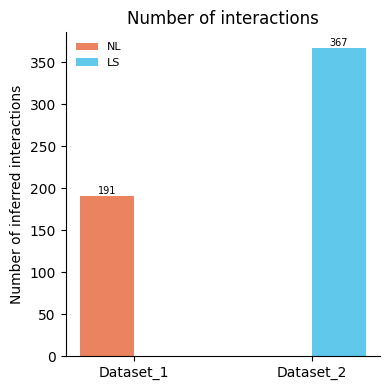

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_01b_compare_interactions_weight.png


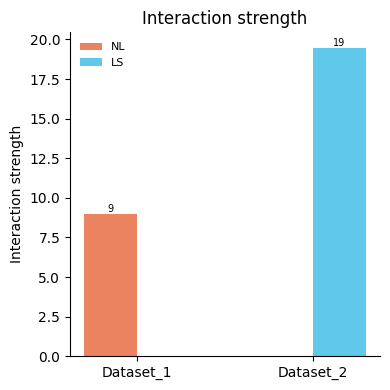

In [8]:
fig1 = cc.compare_interactions(
    [cellchat_NL, cellchat_LS], measure="count",
    group=["NL", "LS"], group_levels=["NL", "LS"],
    title_name="Number of interactions", return_fig=True,
)
save_fig(fig1, "cmp_01a_compare_interactions_count.png")

fig2 = cc.compare_interactions(
    [cellchat_NL, cellchat_LS], measure="weight",
    group=["NL", "LS"], group_levels=["NL", "LS"],
    title_name="Interaction strength", return_fig=True,
)
save_fig(fig2, "cmp_01b_compare_interactions_weight.png")

## (A) Differential number of interactions / strength - circle plot


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_02a_diff_interaction_count.png


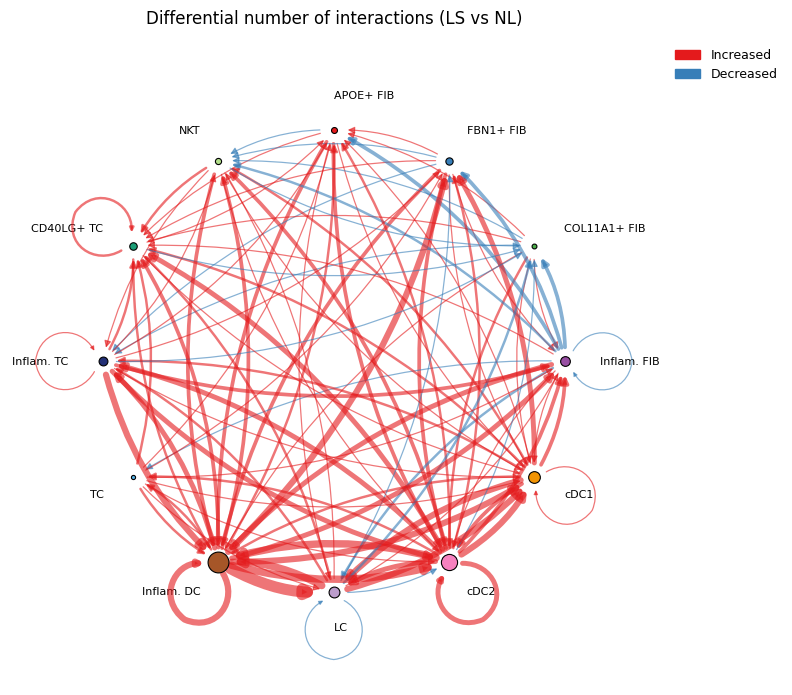

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_02b_diff_interaction_weight.png


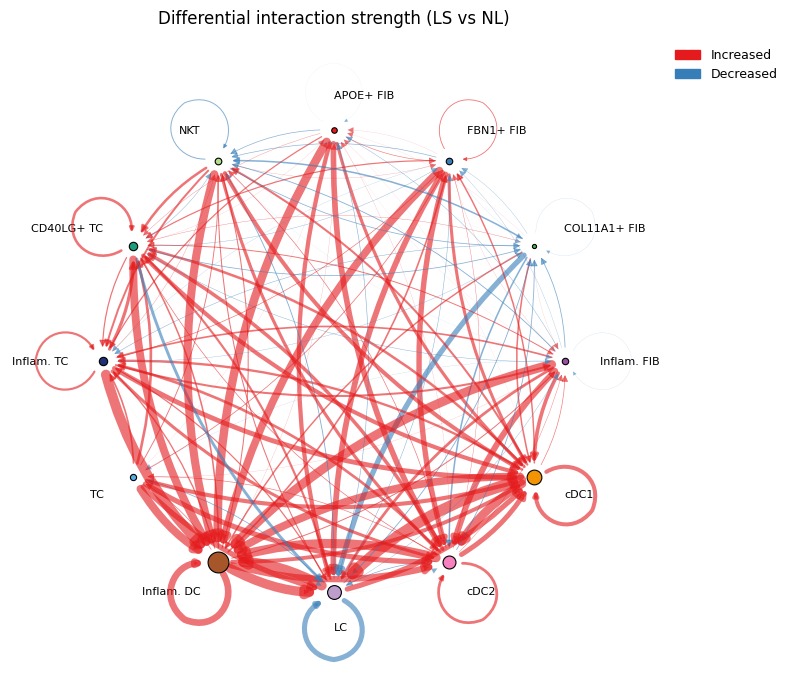

In [9]:
fig1 = cc.plot_network_diff_interaction(
    cellchat_merged, measure="count", comparison=(0, 1),
    title_name="Differential number of interactions (LS vs NL)",
    return_fig=True,
)
save_fig(fig1, "cmp_02a_diff_interaction_count.png")

fig2 = cc.plot_network_diff_interaction(
    cellchat_merged, measure="weight", comparison=(0, 1),
    title_name="Differential interaction strength (LS vs NL)",
    return_fig=True,
)
save_fig(fig2, "cmp_02b_diff_interaction_weight.png")

## (B) Differential number of interactions / strength - heatmap

On a merged object the heatmap is **differential** (LS - NL).

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_03a_diff_heatmap_count.png


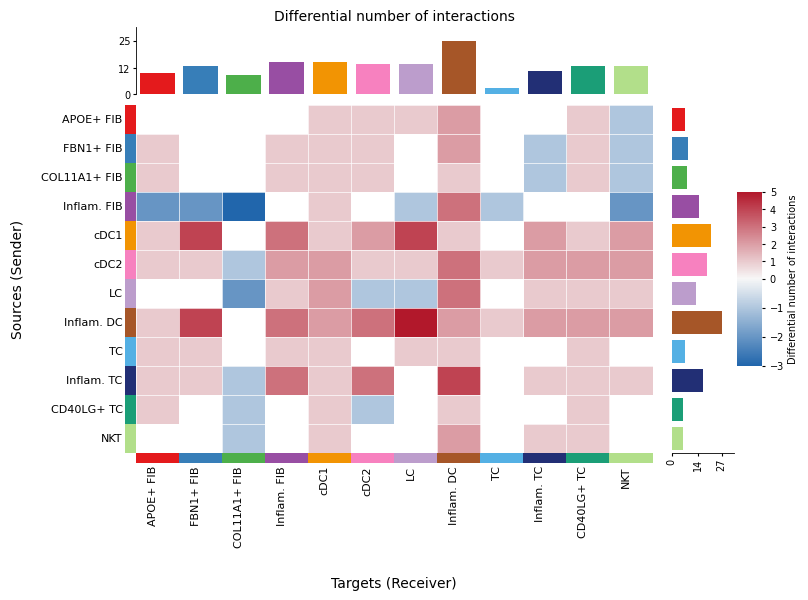

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_03b_diff_heatmap_weight.png


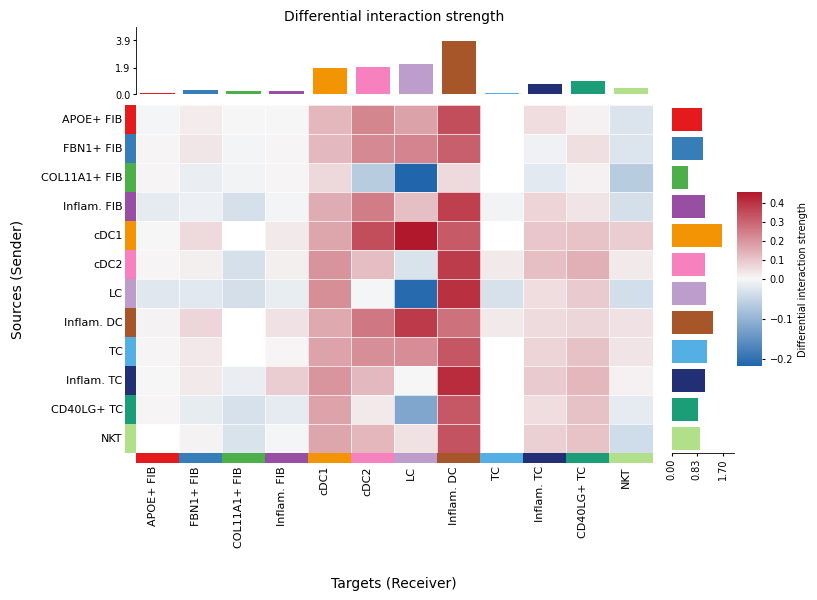

In [10]:
fig1 = cc.plot_network_heatmap(
    cellchat_merged, measure="count",
    title_name="Differential number of interactions", return_fig=True,
)
save_fig(fig1, "cmp_03a_diff_heatmap_count.png")

fig2 = cc.plot_network_heatmap(
    cellchat_merged, measure="weight",
    title_name="Differential interaction strength", return_fig=True,
)
save_fig(fig2, "cmp_03b_diff_heatmap_weight.png")

## (C) Number of interactions per dataset - circle plot


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_04_circle_count_NL.png


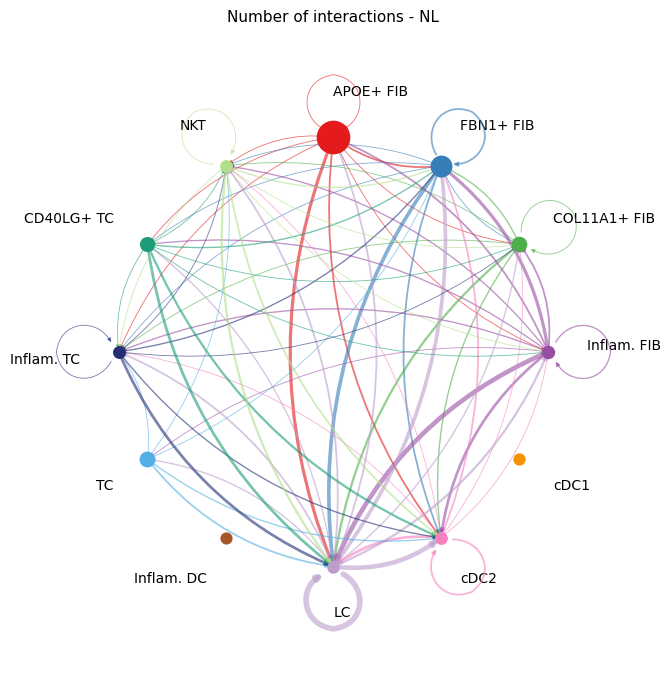

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_04_circle_count_LS.png


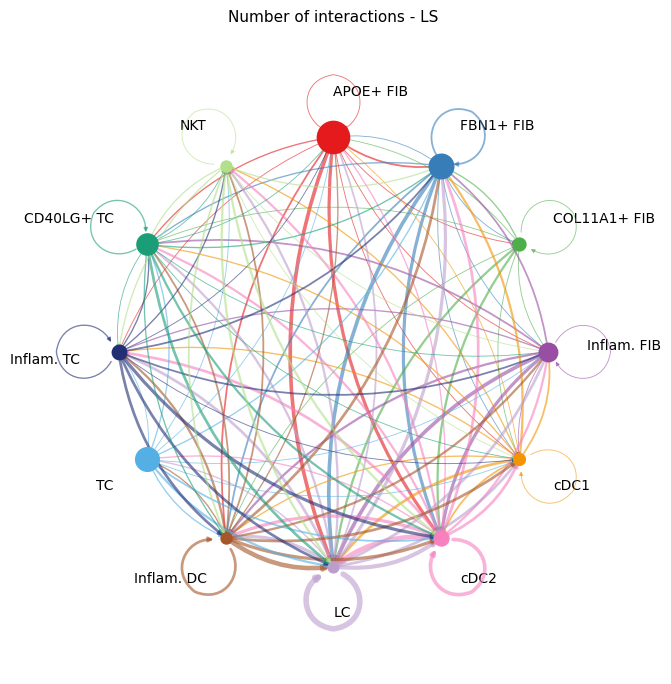

In [11]:
count_max = max(float(np.max(obj.network["count"])) for obj in object_list.values())
for name, obj in object_list.items():
    group_size = [int((obj.groups == group).sum()) for group in obj.groups.categories]
    fig = cc.plot_network_circle(
        obj, net_matrix=obj.network["count"].astype(float),
        vertex_weight=group_size, weight_scale=True,
        edge_weight_max=count_max,
        title_name=f"Number of interactions - {name}", return_fig=True,
    )
    save_fig(fig, f"cmp_04_circle_count_{name}.png")

## (D) Differential interactions among coarse cell types (FIB / DC / TC)


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_05a_circle_count_grouped_NL.png


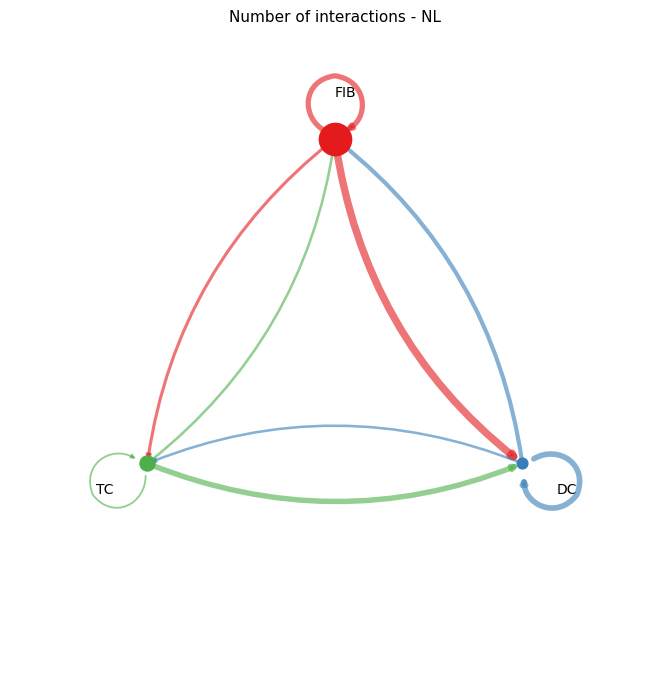

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_05a_circle_count_grouped_LS.png


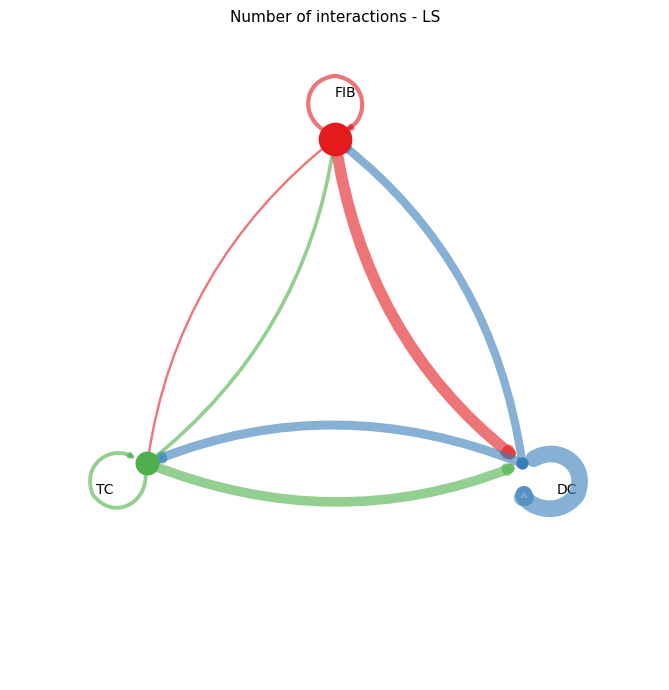

Merging signaling expression, metadata, spatial data, and dataset networks
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_05b_diff_interaction_count_grouped.png


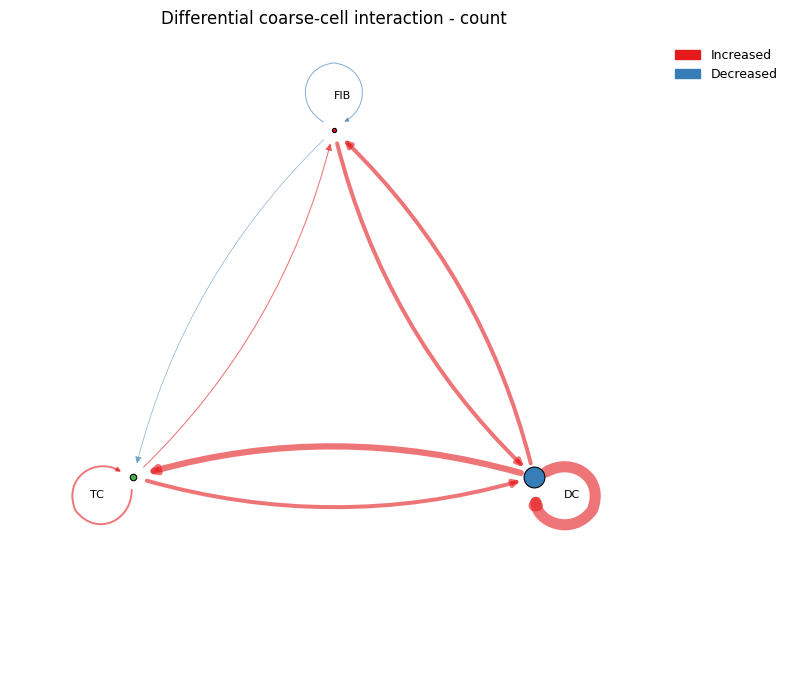

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_05c_diff_interaction_weight_grouped.png


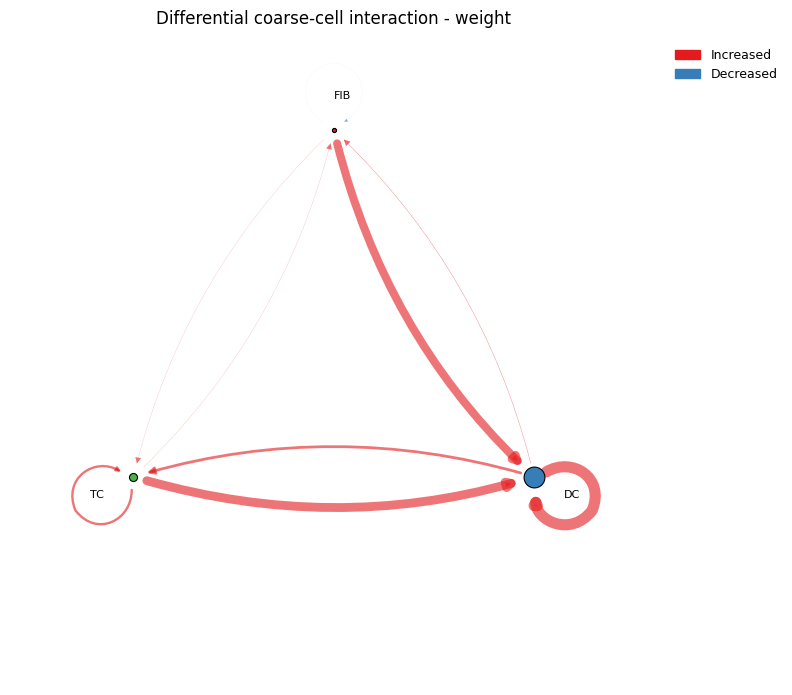

In [12]:
celltype_map = {
    "APOE+ FIB": "FIB", "FBN1+ FIB": "FIB", "COL11A1+ FIB": "FIB", "Inflam. FIB": "FIB",
    "cDC1": "DC", "cDC2": "DC", "LC": "DC", "Inflam. DC": "DC",
    "TC": "TC", "Inflam. TC": "TC", "CD40LG+ TC": "TC", "NKT": "TC",
}
levels0 = list(cellchat_NL.groups.categories)
group_celltype = pd.Categorical(
    [celltype_map[group] for group in levels0], categories=["FIB", "DC", "TC"]
)

cellchat_NL_grouped = cc.merge_interactions(cellchat_NL, group_celltype)
cellchat_LS_grouped = cc.merge_interactions(cellchat_LS, group_celltype)
grouped_objects = {"NL": cellchat_NL_grouped, "LS": cellchat_LS_grouped}
count_merged_max = max(
    float(np.max(obj.network["count"])) for obj in grouped_objects.values()
)

for name, obj in grouped_objects.items():
    fig = cc.plot_network_circle(
        obj, net_matrix=obj.network["count"].astype(float),
        weight_scale=True, edge_weight_max=count_merged_max,
        edge_width_max=12,
        title_name=f"Number of interactions - {name}", return_fig=True,
    )
    save_fig(fig, f"cmp_05a_circle_count_grouped_{name}.png")

cellchat_grouped = cc.merge_cellchat(
    [cellchat_NL_grouped, cellchat_LS_grouped], add_names=["NL", "LS"]
)
for measure, filename in [
    ("count", "cmp_05b_diff_interaction_count_grouped.png"),
    ("weight", "cmp_05c_diff_interaction_weight_grouped.png"),
]:
    fig = cc.plot_network_diff_interaction(
        cellchat_grouped, comparison=(0, 1), measure=measure,
        title_name=f"Differential coarse-cell interaction - {measure}",
        return_fig=True,
    )
    save_fig(fig, filename)

## Compare major sources and targets in 2D space


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_06_role_scatter_NL.png


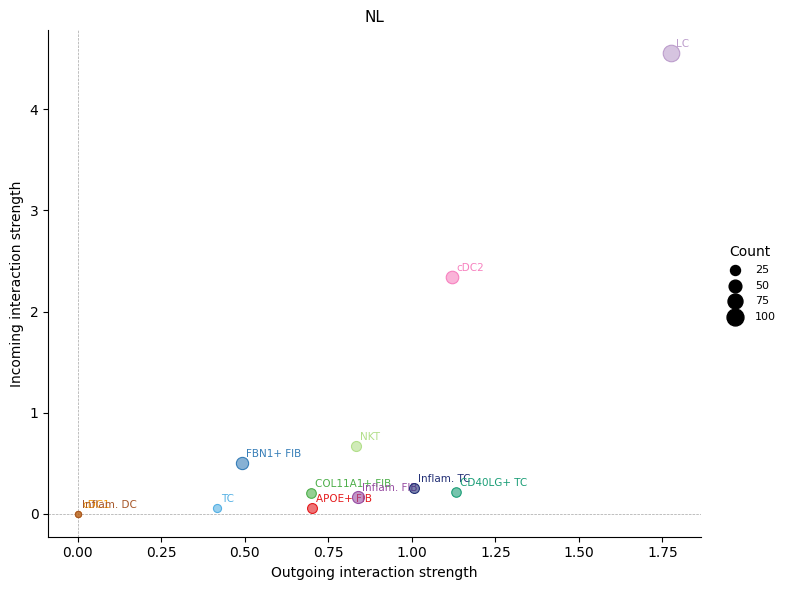

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_06_role_scatter_LS.png


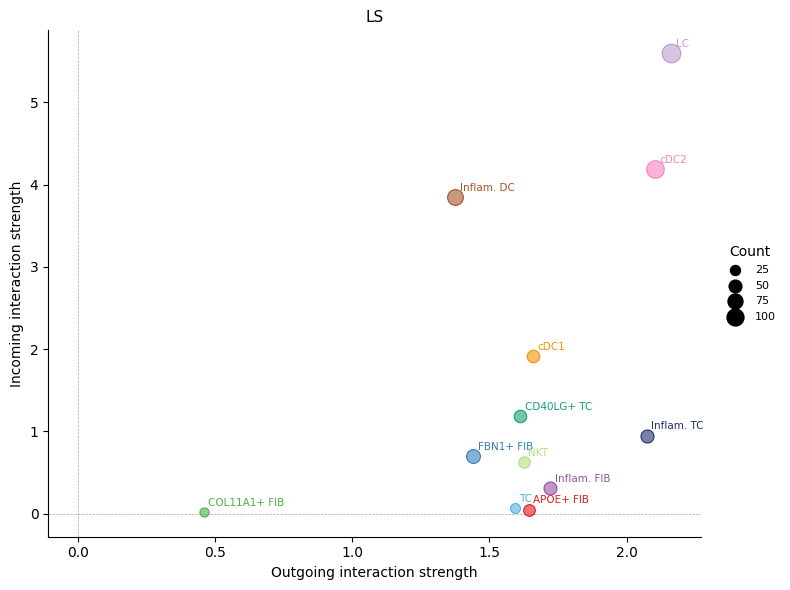

In [13]:
link_counts = []
for obj in object_list.values():
    count = obj.network["count"].astype(float)
    link_counts.append(count.sum(axis=1) + count.sum(axis=0) - np.diag(count))
weight_min_max = (float(np.concatenate(link_counts).min()), float(np.concatenate(link_counts).max()))

for name, obj in object_list.items():
    fig = cc.net_analysis_signaling_role_scatter(
        obj, title=name, weight_min_max=weight_min_max, return_fig=True
    )
    save_fig(fig, f"cmp_06_role_scatter_{name}.png")

## (B) Signaling changes of specific cell populations


Visualizing signaling changes for Inflam. DC from NL to LS
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_07_signaling_changes_Inflam_DC.png


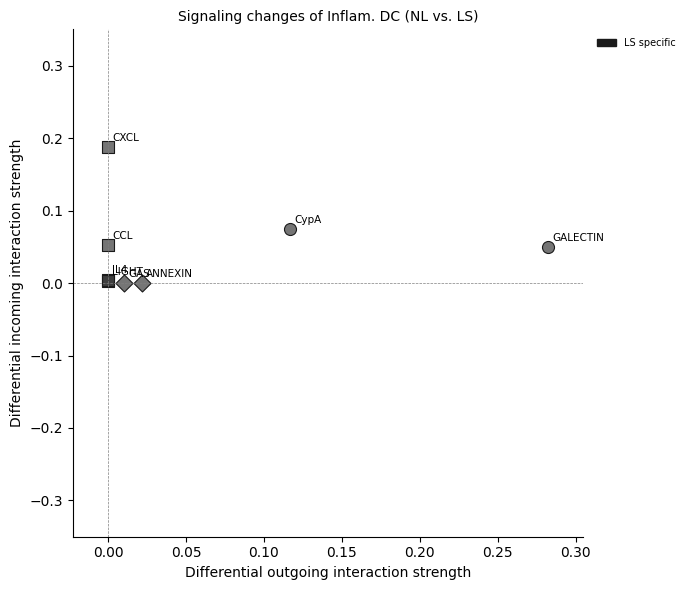

Visualizing signaling changes for cDC1 from NL to LS
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_07_signaling_changes_cDC1.png


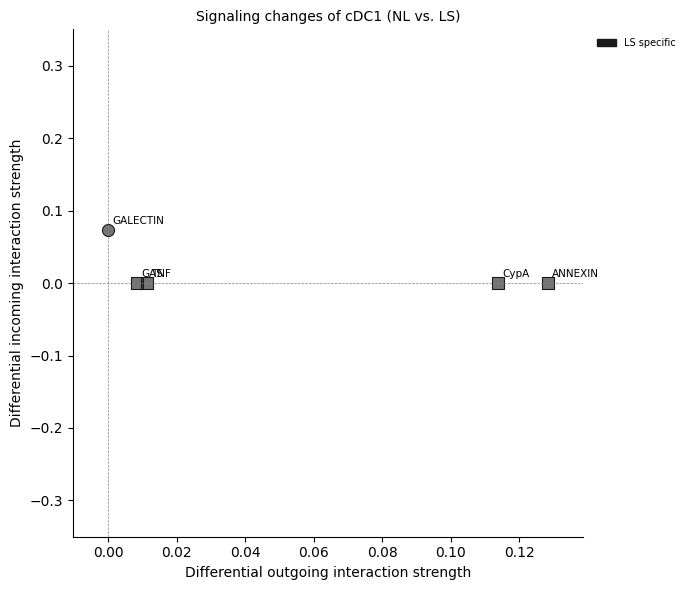

In [29]:
for cell_group in ["Inflam. DC", "cDC1"]:
    fig = cc.net_analysis_signaling_changes_scatter(
        cellchat_merged, group_use=cell_group, comparison=[0, 1],
        signaling_exclude=["MIF"], ylims=(-0.35, 0.35), return_fig=True,
    )
    safe_name = cell_group.replace(" ", "_").replace(".", "")
    save_fig(fig, f"cmp_07_signaling_changes_{safe_name}.png")

---
## Part II: Identify altered signaling with distinct network architecture

Identify signaling networks with larger/smaller differences and group pathways by functional / structural similarity in a joint manifold.

## Functional similarity - joint manifold


Compute signaling network similarity for datasets [0, 1]
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_08_embedding_pairwise_functional.png


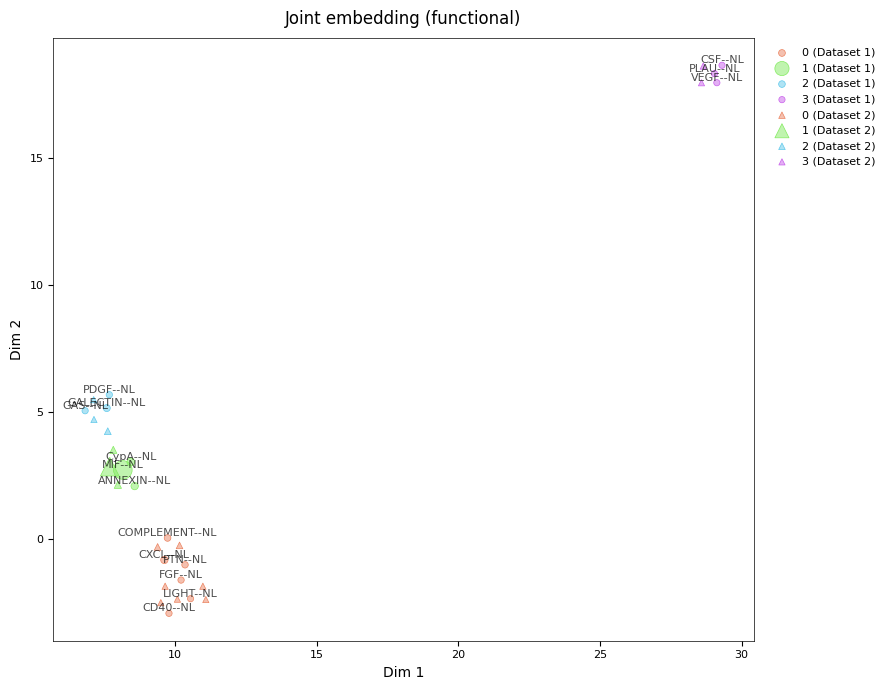

In [15]:
cellchat_merged = cc.compute_pairwise_network_similarity(
    cellchat_merged, type="functional", comparison=[0, 1]
)
cellchat_merged = cc.embed_network(
    cellchat_merged, type="functional", comparison=[0, 1]
)
cellchat_merged = cc.cluster_network(
    cellchat_merged, type="functional", comparison=[0, 1]
)
fig = cc.plot_network_embedding_pairwise(
    cellchat_merged, emb_type="functional", comparison=(0, 1), return_fig=True
)
save_fig(fig, "cmp_08_embedding_pairwise_functional.png")

## Structural similarity - joint manifold


Compute signaling network similarity for datasets [0, 1]
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_09_embedding_pairwise_structural.png


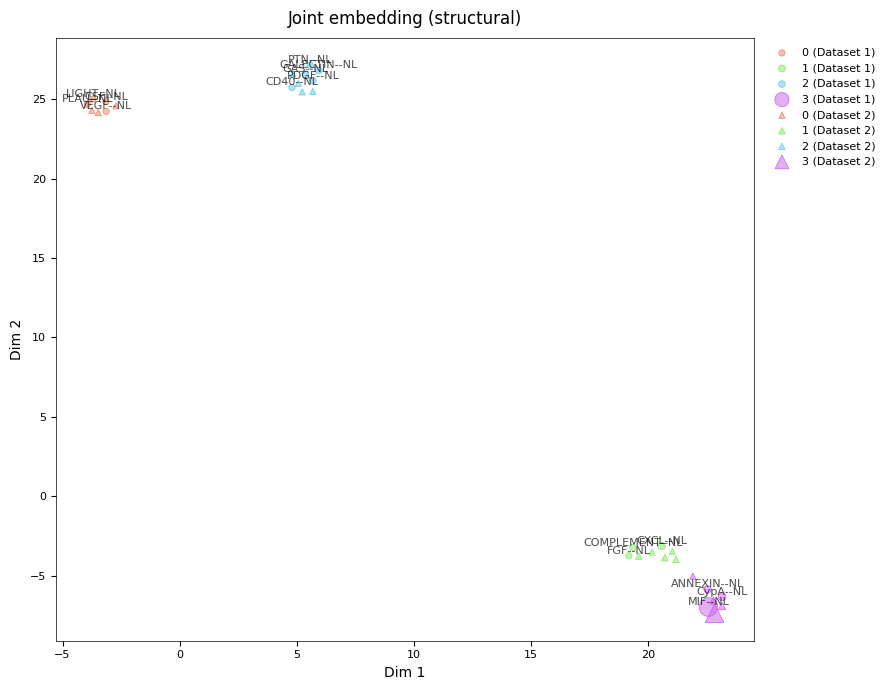

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_09_zoom_in_embedding_pairwise_structural.png


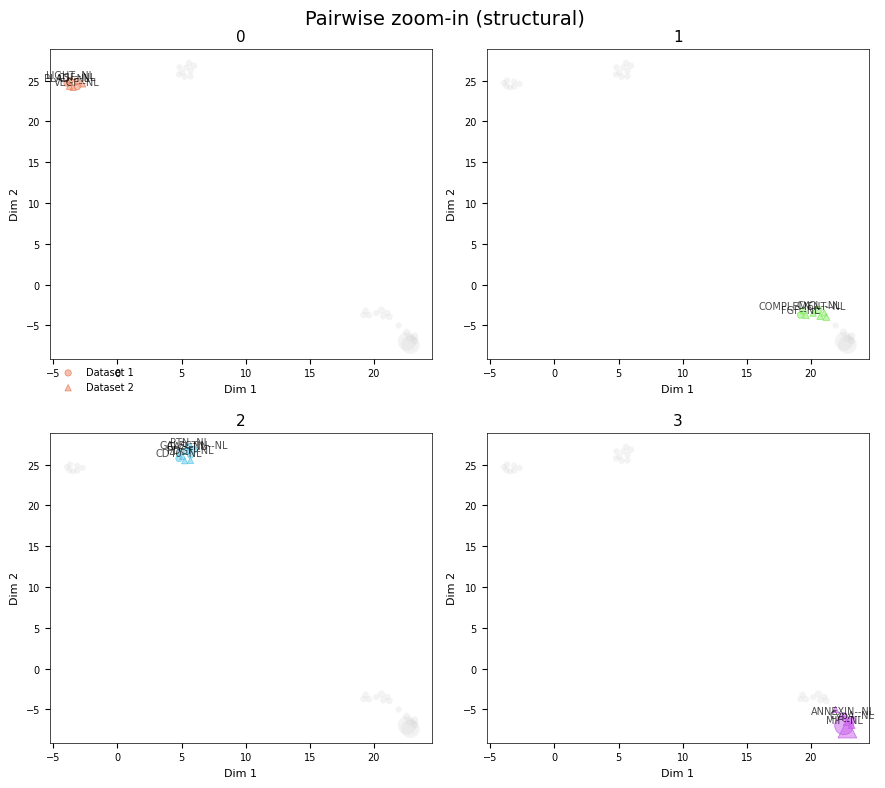

In [16]:
cellchat_merged = cc.compute_pairwise_network_similarity(
    cellchat_merged, type="structural", comparison=[0, 1]
)
cellchat_merged = cc.embed_network(
    cellchat_merged, type="structural", comparison=[0, 1]
)
cellchat_merged = cc.cluster_network(
    cellchat_merged, type="structural", comparison=[0, 1]
)
fig = cc.plot_network_embedding_pairwise(
    cellchat_merged, emb_type="structural", comparison=(0, 1), return_fig=True
)
save_fig(fig, "cmp_09_embedding_pairwise_structural.png")
fig = cc.plot_network_embedding_pairwise_zoom_in(
    cellchat_merged, emb_type="structural", comparison=(0, 1),
    ncol=2, return_fig=True,
)
save_fig(fig, "cmp_09_zoom_in_embedding_pairwise_structural.png")

## Pathway distance in the learned joint manifold
```r
rankSimilarity
```

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_10_rank_similarity_functional.png


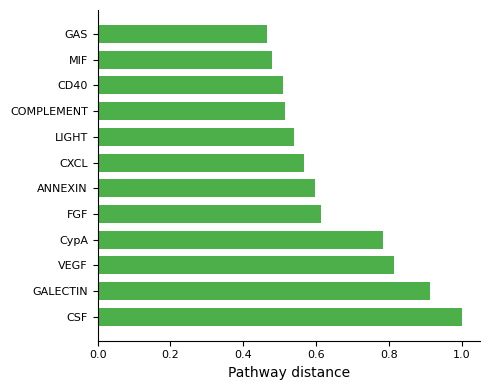

In [30]:
fig = cc.rank_similarity(cellchat_merged, type="functional", return_fig=True)
save_fig(fig, "cmp_10_rank_similarity_functional.png")

## (A) Compare the overall information flow of each signaling pathway


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_11a_rank_net_stacked.png


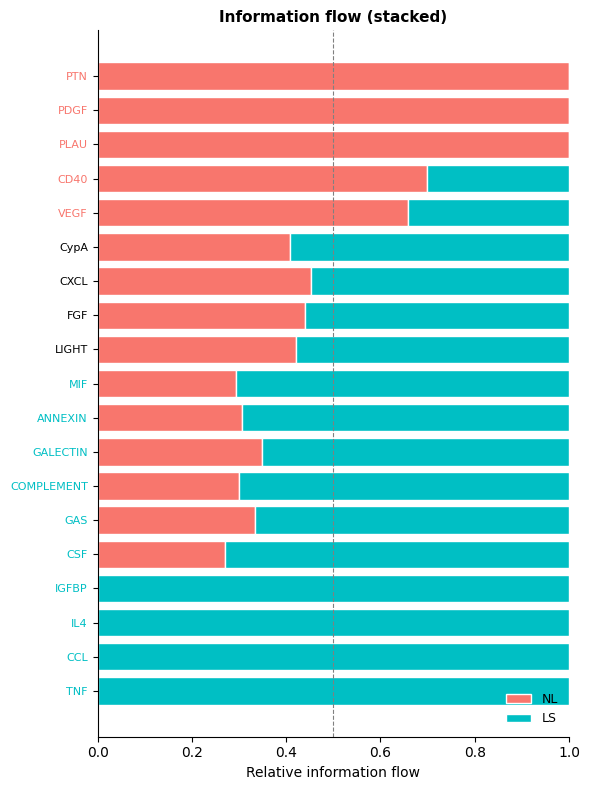

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_11b_rank_net_unstacked.png


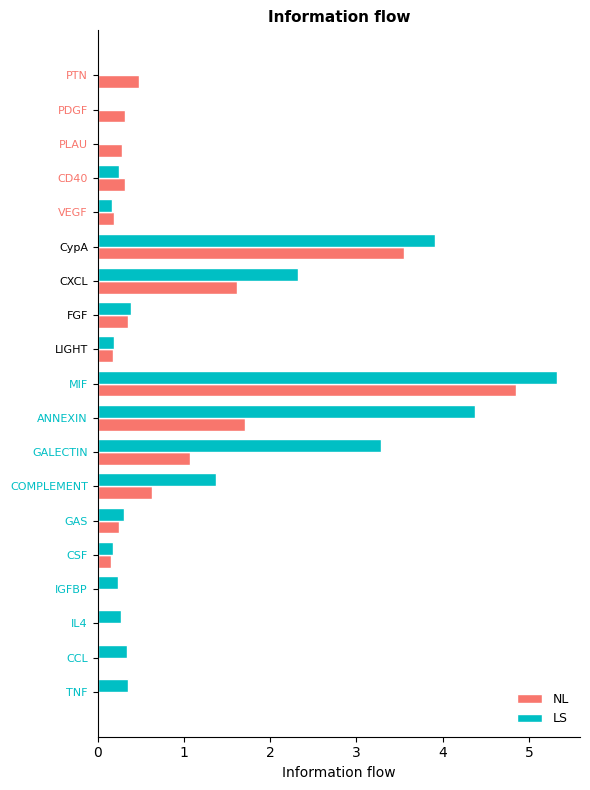

In [18]:
fig1 = cc.rank_net(
    cellchat_merged, mode="comparison", measure="weight", comparison=(0, 1),
    stacked=True, do_stat=True, title="Information flow (stacked)", return_fig=True,
)
save_fig(fig1, "cmp_11a_rank_net_stacked.png")

fig2 = cc.rank_net(
    cellchat_merged, mode="comparison", measure="weight", comparison=(0, 1),
    stacked=False, do_stat=True, title="Information flow", return_fig=True,
)
save_fig(fig2, "cmp_11b_rank_net_unstacked.png")

## (B) Outgoing / incoming signaling patterns per cell population


Pathway union (19): ['MIF', 'CypA', 'ANNEXIN', 'CXCL', 'GALECTIN', 'COMPLEMENT', 'PTN', 'FGF', 'PDGF', 'CD40', 'PLAU', 'GAS', 'VEGF', 'LIGHT', 'CSF', 'TNF', 'CCL', 'IL4', 'IGFBP']
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_outgoing_NL.png


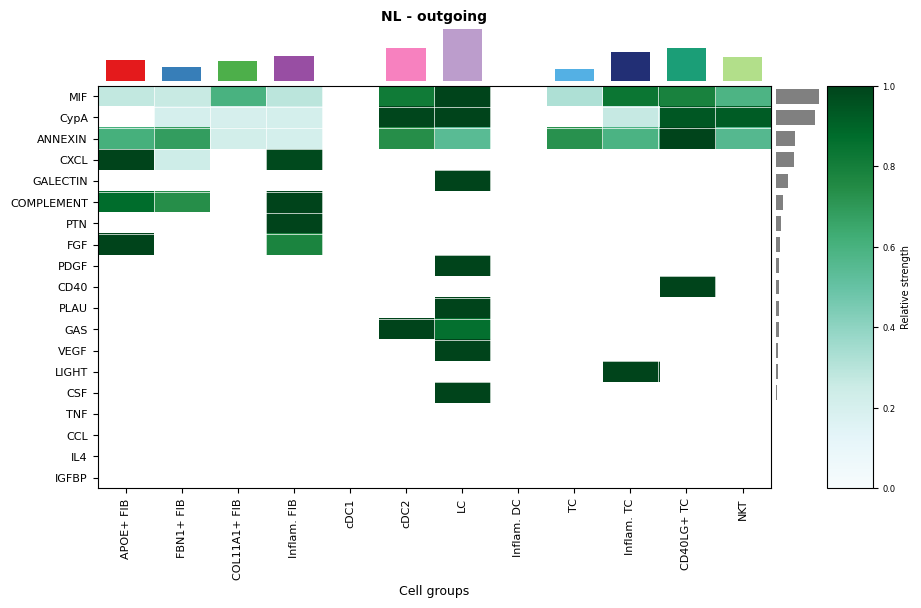

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_outgoing_LS.png


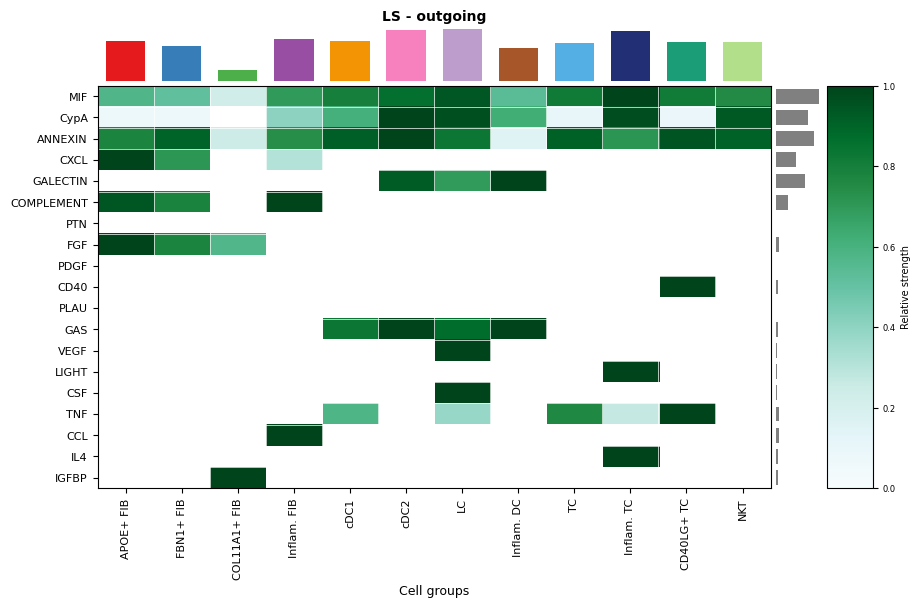

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_incoming_NL.png


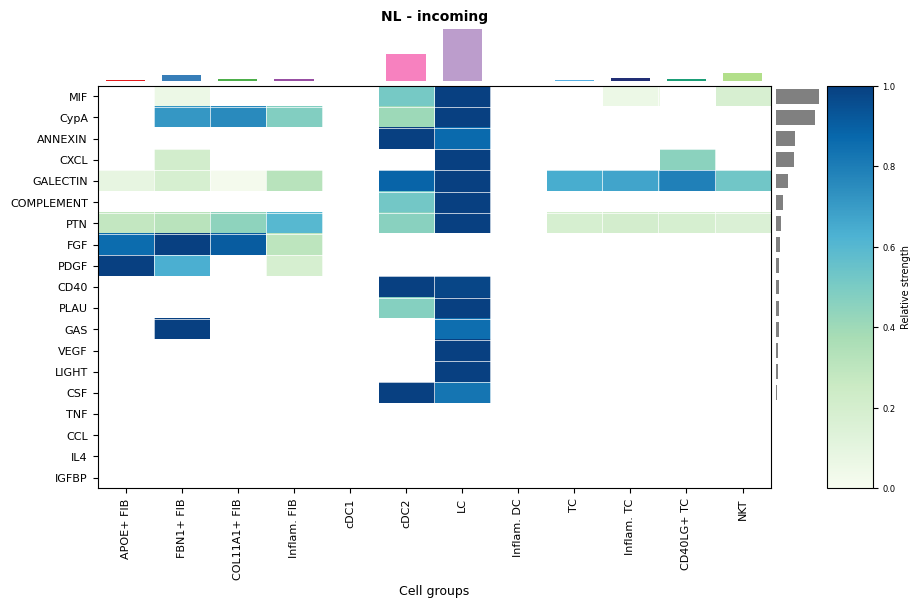

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_incoming_LS.png


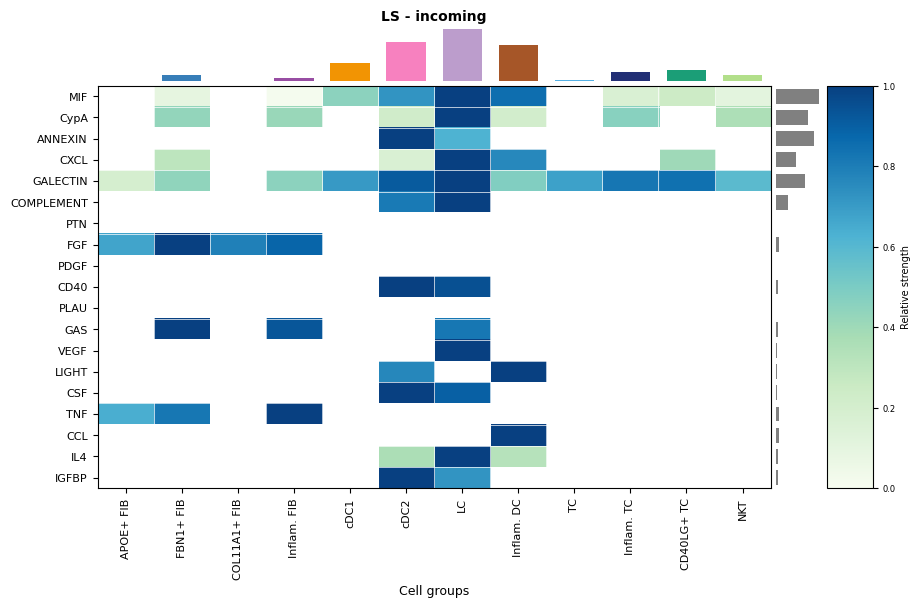

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_all_NL.png


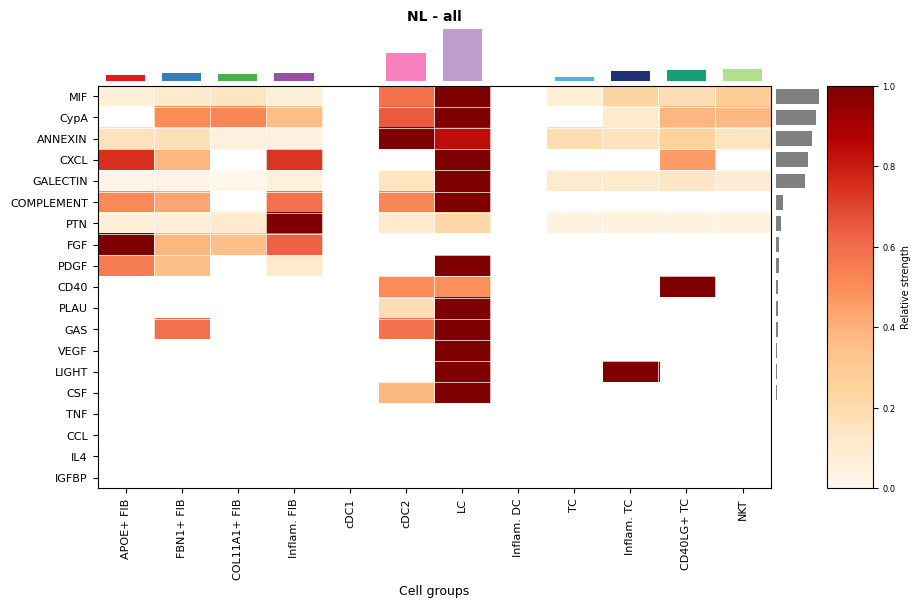

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_12_role_heatmap_all_LS.png


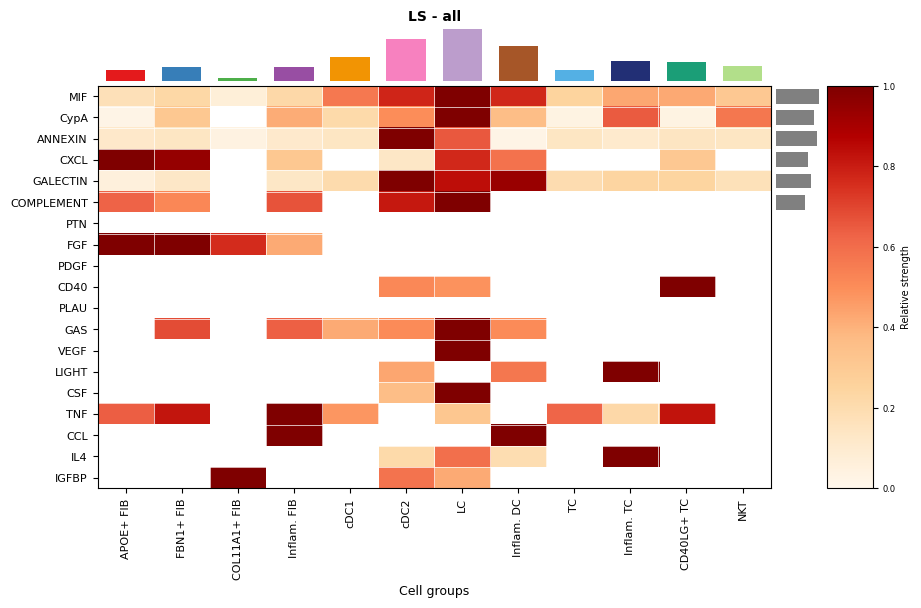

In [19]:
pathway_union = list(dict.fromkeys(
    list(cellchat_NL.pathway_network.get("prob", {}))
    + list(cellchat_LS.pathway_network.get("prob", {}))
))
print(f"Pathway union ({len(pathway_union)}): {pathway_union}")

for pattern, color_heatmap in {"outgoing": "BuGn", "incoming": "GnBu", "all": "OrRd"}.items():
    for name, obj in object_list.items():
        fig = cc.net_analysis_signaling_role_heatmap(
            obj, pattern=pattern, signaling=pathway_union,
            color_heatmap=color_heatmap, title=f"{name} - {pattern}", return_fig=True,
        )
        save_fig(fig, f"cmp_12_role_heatmap_{pattern}_{name}.png")

---
## Part III: Identify up-regulated and down-regulated signaling L-R pairs

Two approaches: (1) compare communication probabilities directly, (2) differential expression analysis across datasets.

## Identify dysfunctional signaling by comparing communication probabilities


source: ['Inflam. FIB']
targets: ['cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC']
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_13_bubble_comparison.png


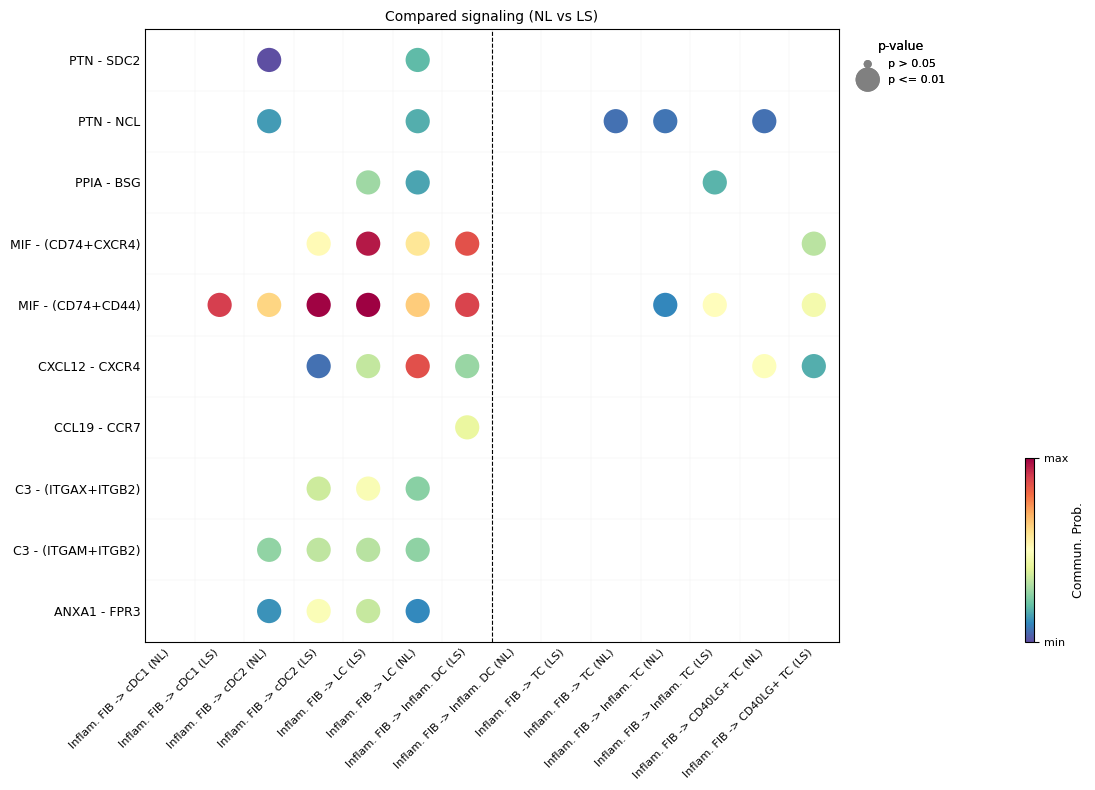

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_13a_bubble_increased_LS.png


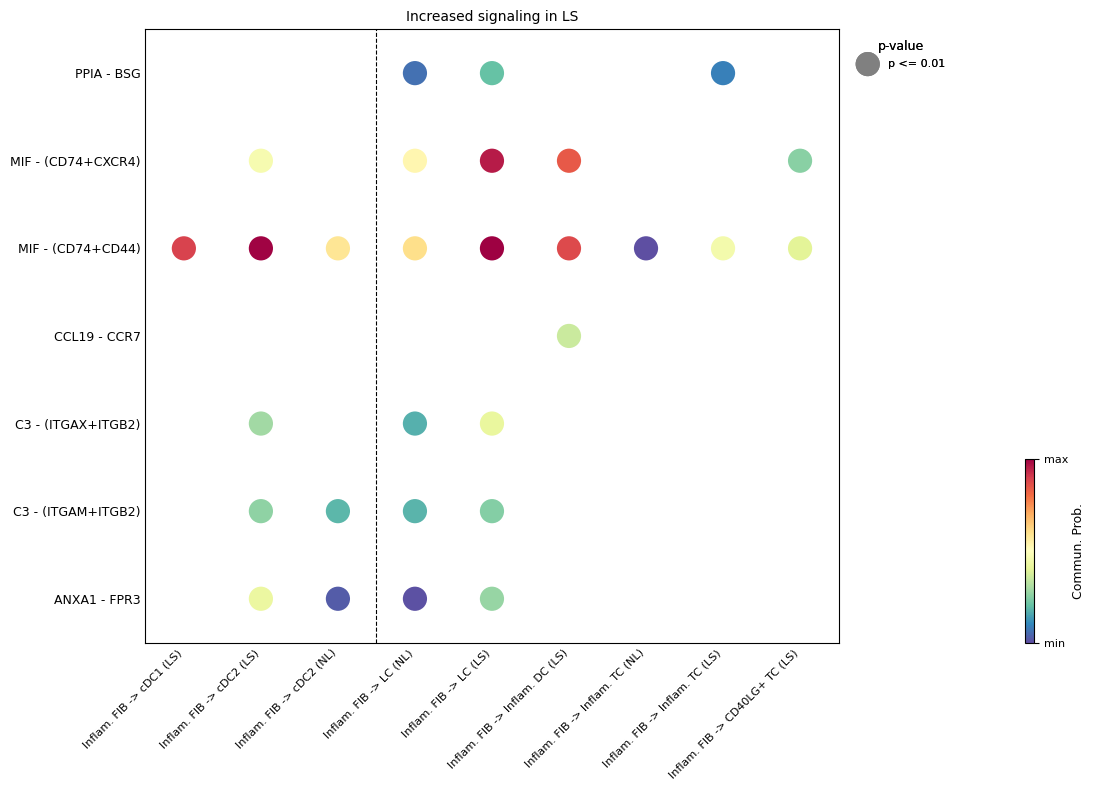

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_13b_bubble_decreased_LS.png


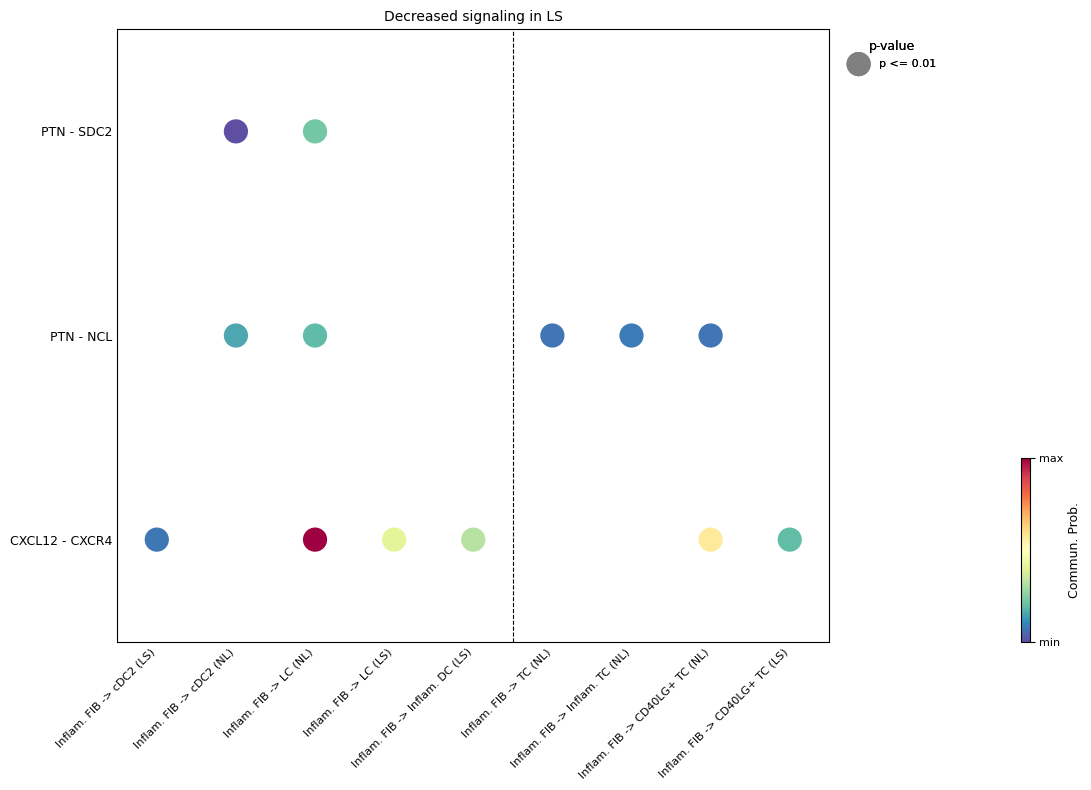

In [20]:
levels0 = list(cellchat_NL.groups.categories)
source_use = [levels0[3]]
targets_use = levels0[4:11]
print("source:", source_use)
print("targets:", targets_use)

fig = cc.plot_network_bubble(
    cellchat_merged, sources_use=source_use, targets_use=targets_use,
    comparison=(0, 1), angle_x=45,
    title_name="Compared signaling (NL vs LS)", return_fig=True,
)
save_fig(fig, "cmp_13_bubble_comparison.png")

fig = cc.plot_network_bubble(
    cellchat_merged, sources_use=source_use, targets_use=targets_use,
    comparison=(0, 1), max_dataset=2, remove_isolate=True, angle_x=45,
    title_name="Increased signaling in LS", return_fig=True,
)
save_fig(fig, "cmp_13a_bubble_increased_LS.png")

fig = cc.plot_network_bubble(
    cellchat_merged, sources_use=source_use, targets_use=targets_use,
    comparison=(0, 1), max_dataset=1, remove_isolate=True, angle_x=45,
    title_name="Decreased signaling in LS", return_fig=True,
)
save_fig(fig, "cmp_13b_bubble_decreased_LS.png")

## Identify dysfunctional signaling by differential expression analysis


In [21]:
pos_dataset = "LS"
features_name = f"{pos_dataset}.merged"
cellchat_merged = cc.identify_overexpressed_genes(
    cellchat_merged, group_dataset="cellchat_dataset", pos_dataset=pos_dataset,
    features_name=features_name, only_pos=False,
    thresh_pc=0.1, thresh_fc=0.05, thresh_p=0.05,
)
info = cellchat_merged.feature_results.get(f"{features_name}_info")
print(f"DE genes table: {0 if info is None else len(info)} rows")

net = cc.map_network_deg(cellchat_merged, features_name=features_name)
net_up = cc.subset_communication(
    cellchat_merged, network_table=net, dataset_names="LS", ligand_log_fc=0.05
)
net_down = cc.subset_communication(
    cellchat_merged, network_table=net, dataset_names="NL", ligand_log_fc=-0.05
)
print(f"Up-regulated in LS:   {len(net_up)} LR pairs")
print(f"Down-regulated in LS: {len(net_down)} LR pairs")
if len(net_up):
    display(net_up.head(8))

DE genes table: 542 rows
Up-regulated in LS:   117 LR pairs
Down-regulated in LS: 13 LR pairs


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,...,source_ligand,target_receptor,ligand_pvalues,ligand_log_fc,ligand_pct_1,ligand_pct_2,receptor_pvalues,receptor_log_fc,receptor_pct_1,receptor_pct_2
0,APOE+ FIB,APOE+ FIB,FGF7,FGFR1,0.006276,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,APOE+ FIB.FGF7,APOE+ FIB.FGFR1,7.016894e-20,0.500732,44.869707,27.901235,0.032325,-0.12823,25.814332,28.395062
1,APOE+ FIB,FBN1+ FIB,FGF7,FGFR1,0.009363,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,APOE+ FIB.FGF7,FBN1+ FIB.FGFR1,7.016894e-20,0.500732,44.869707,27.901235,NaN,NaN,NaN,NaN
2,APOE+ FIB,COL11A1+ FIB,FGF7,FGFR1,0.007386,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,APOE+ FIB.FGF7,COL11A1+ FIB.FGFR1,7.016894e-20,0.500732,44.869707,27.901235,NaN,NaN,NaN,NaN
3,APOE+ FIB,Inflam. FIB,FGF7,FGFR1,0.008251,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,APOE+ FIB.FGF7,Inflam. FIB.FGFR1,7.016894e-20,0.500732,44.869707,27.901235,NaN,NaN,NaN,NaN
4,FBN1+ FIB,APOE+ FIB,FGF7,FGFR1,0.004855,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,FBN1+ FIB.FGF7,APOE+ FIB.FGFR1,4.158468e-16,0.485855,41.697417,21.532847,0.032325,-0.12823,25.814332,28.395062
5,FBN1+ FIB,FBN1+ FIB,FGF7,FGFR1,0.007247,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,FBN1+ FIB.FGF7,FBN1+ FIB.FGFR1,4.158468e-16,0.485855,41.697417,21.532847,NaN,NaN,NaN,NaN
6,FBN1+ FIB,COL11A1+ FIB,FGF7,FGFR1,0.005715,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,FBN1+ FIB.FGF7,COL11A1+ FIB.FGFR1,4.158468e-16,0.485855,41.697417,21.532847,NaN,NaN,NaN,NaN
7,FBN1+ FIB,Inflam. FIB,FGF7,FGFR1,0.006385,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,...,FBN1+ FIB.FGF7,Inflam. FIB.FGFR1,4.158468e-16,0.485855,41.697417,21.532847,NaN,NaN,NaN,NaN


## Visualize up/down-regulated L-R pairs - bubble plot


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_14a_bubble_up.png


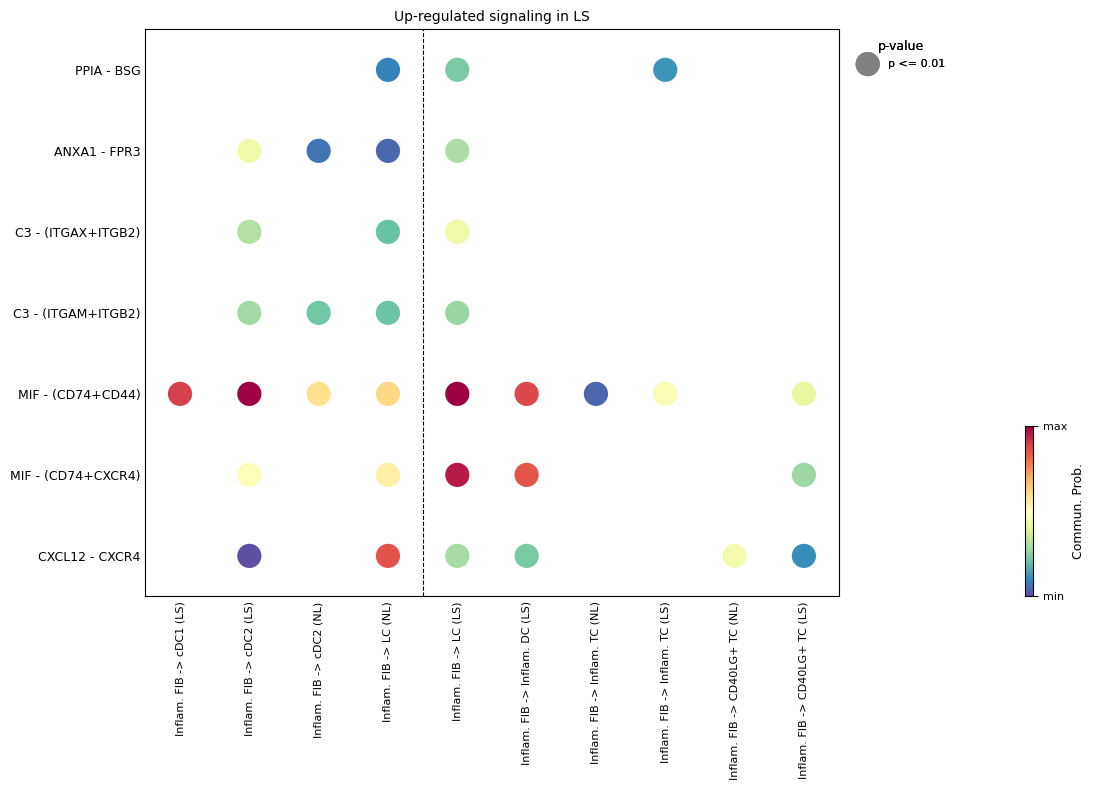

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_14b_bubble_down.png


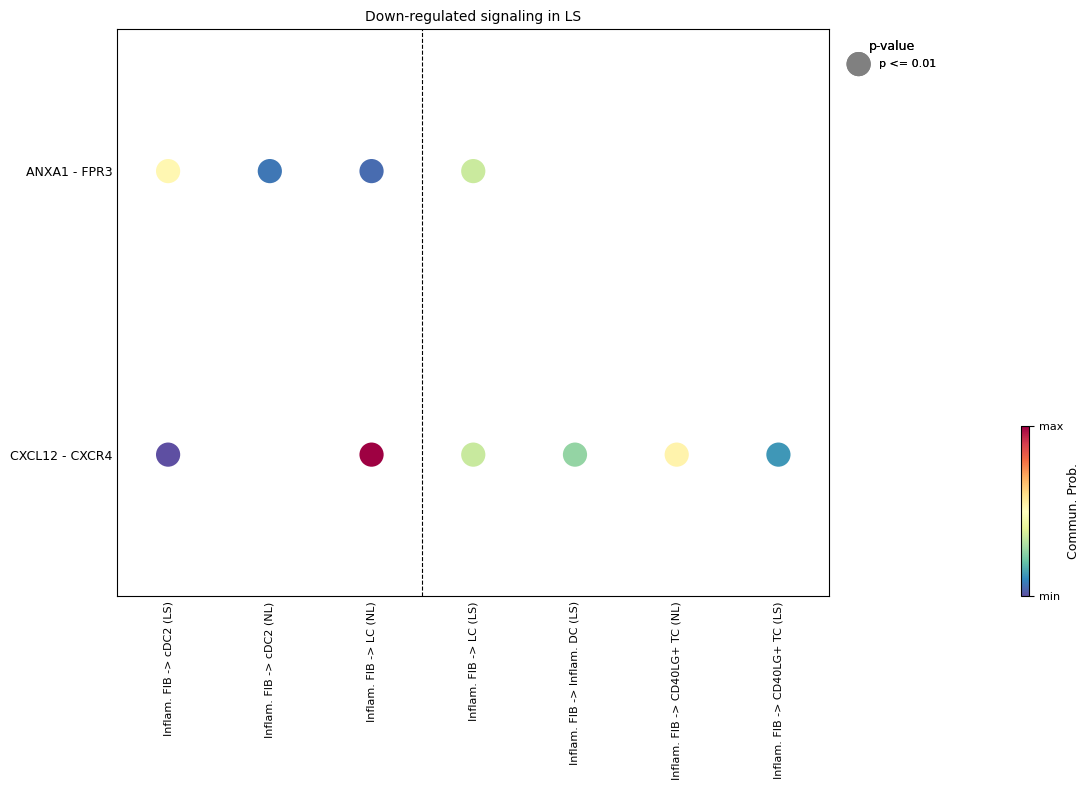

In [22]:
if len(net_up) and "interaction_name" in net_up.columns:
    pair_lr_up = net_up[["interaction_name"]].drop_duplicates()
    fig = cc.plot_network_bubble(
        cellchat_merged, sources_use=source_use, targets_use=targets_use,
        comparison=(0, 1), pair_lr_use=pair_lr_up, remove_isolate=True,
        angle_x=90, title_name="Up-regulated signaling in LS", return_fig=True,
    )
    save_fig(fig, "cmp_14a_bubble_up.png")

if len(net_down) and "interaction_name" in net_down.columns:
    pair_lr_down = net_down[["interaction_name"]].drop_duplicates()
    fig = cc.plot_network_bubble(
        cellchat_merged, sources_use=source_use, targets_use=targets_use,
        comparison=(0, 1), pair_lr_use=pair_lr_down, remove_isolate=True,
        angle_x=90, title_name="Down-regulated signaling in LS", return_fig=True,
    )
    save_fig(fig, "cmp_14b_bubble_down.png")

## Visualize up/down-regulated L-R pairs - chord diagram & enrichment


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_15a_chord_up.png


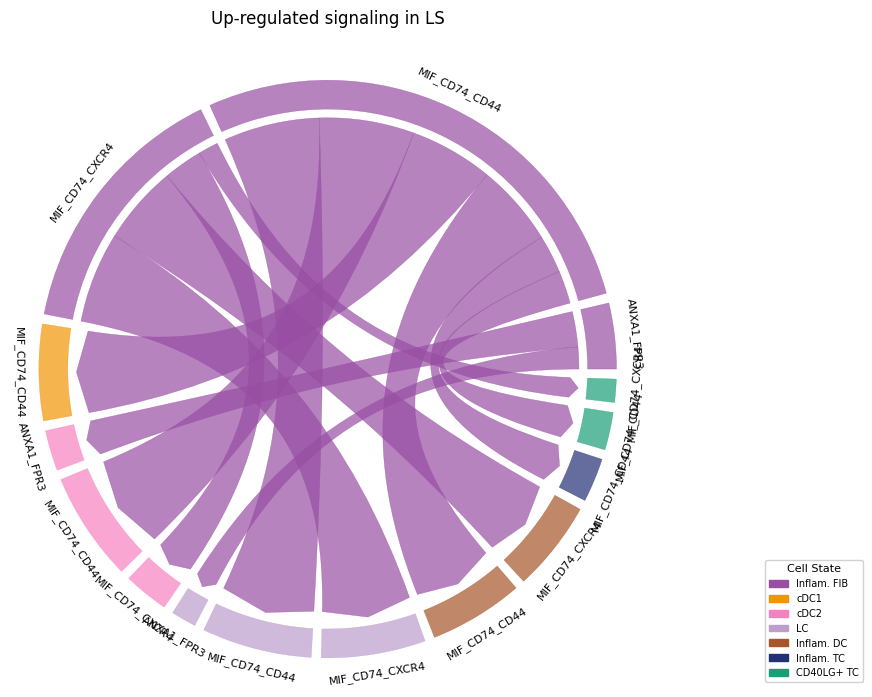

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_15b_chord_down.png


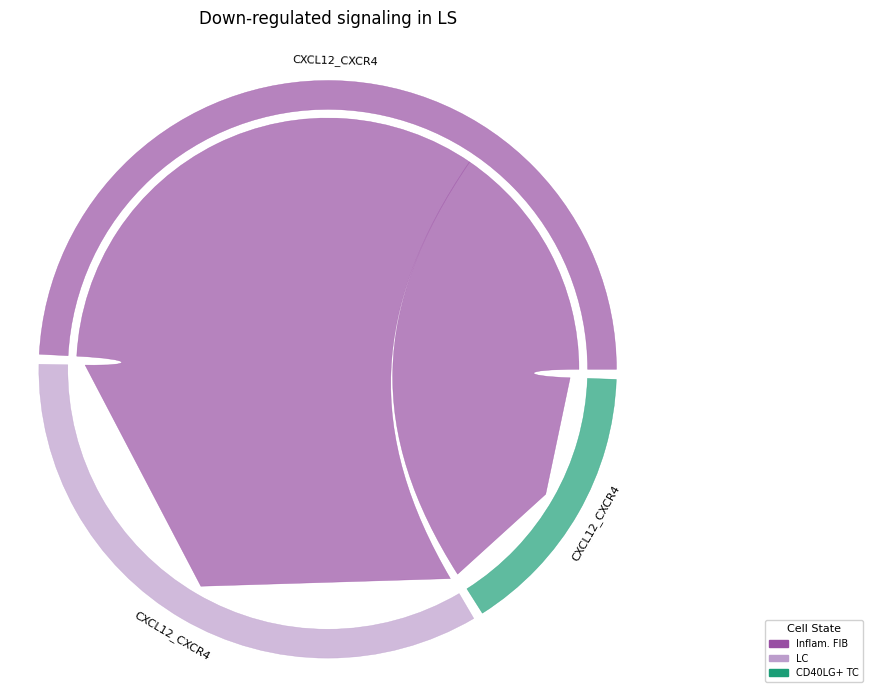

,ligand,total
0,MIF,85.702375
1,CXCL12,65.747756
2,IL13,64.558887
3,FGF7,3.026942


In [23]:
if len(net_up):
    fig = cc.plot_network_chord_gene(
        cellchat_LS, sources_use=source_use, targets_use=targets_use,
        slot_name="network", network_table=net_up,
        title_name="Up-regulated signaling in LS", return_fig=True,
    )
    save_fig(fig, "cmp_15a_chord_up.png")

if len(net_down):
    fig = cc.plot_network_chord_gene(
        cellchat_NL, sources_use=source_use, targets_use=targets_use,
        slot_name="network", network_table=net_down,
        title_name="Down-regulated signaling in LS", return_fig=True,
    )
    save_fig(fig, "cmp_15b_chord_down.png")

if len(net_up):
    enrichment_up = cc.compute_enrichment_score(net_up, species="human")
    if enrichment_up is not None:
        display(enrichment_up.head(10))

---
## Part IV: Visually compare cell-cell communication

Compare a specific signaling pathway (**CXCL**) across datasets using circle / heatmap / chord plots.

## CXCL pathway - circle plot per dataset


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16a_circle_CXCL_NL.png


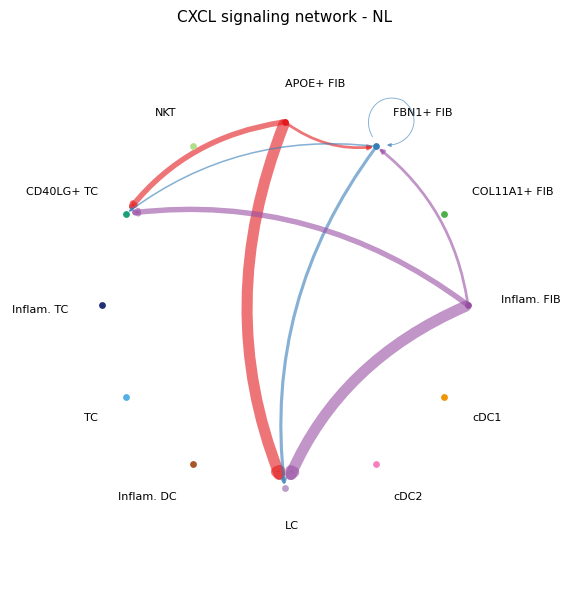

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16a_circle_CXCL_LS.png


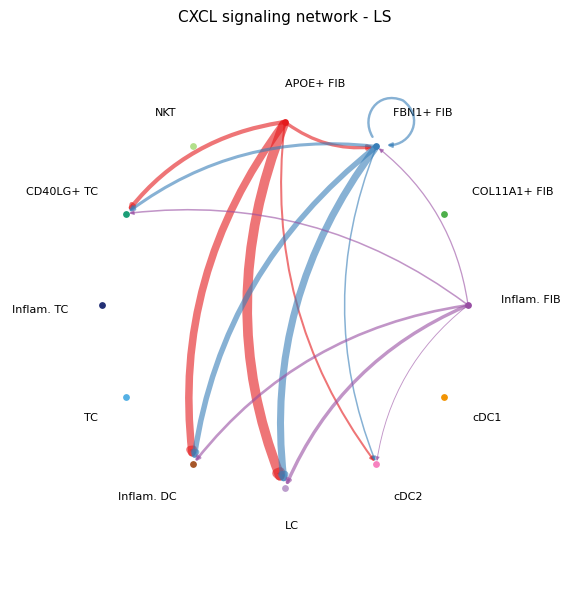

In [24]:
pathway_show = "CXCL"
object_list = {"NL": cellchat_NL, "LS": cellchat_LS}
edge_max = cc.get_max_weight(
    list(object_list.values()), slot_name="pathway_network", attribute=pathway_show
)[pathway_show]

for name, obj in object_list.items():
    if pathway_show not in obj.pathway_network.get("prob", {}):
        continue
    fig = cc.plot_network_aggregate(
        obj, signaling=pathway_show, layout="circle", edge_weight_max=edge_max,
        title_name=f"{pathway_show} signaling network - {name}", return_fig=True,
    )
    save_fig(fig, f"cmp_16a_circle_{pathway_show}_{name}.png")

## CXCL pathway - heatmap per dataset


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16b_heatmap_CXCL_NL.png


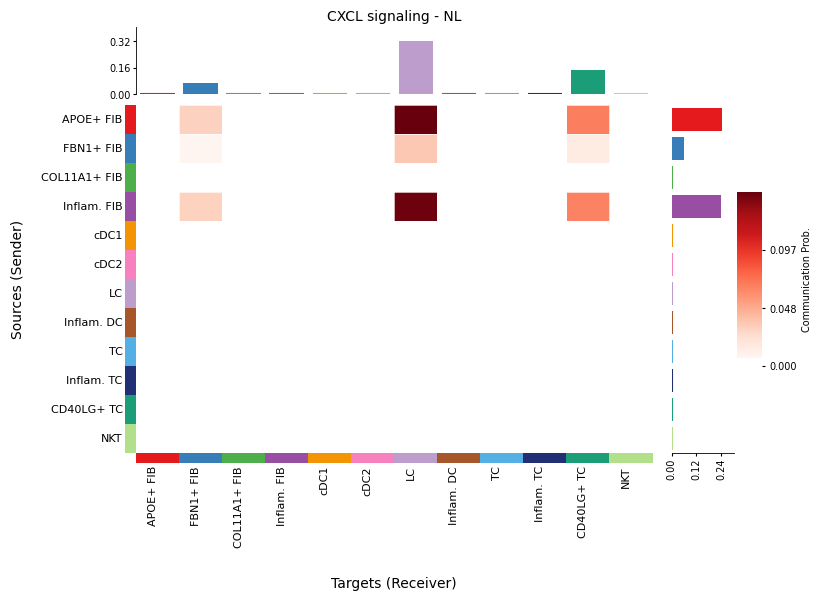

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16b_heatmap_CXCL_LS.png


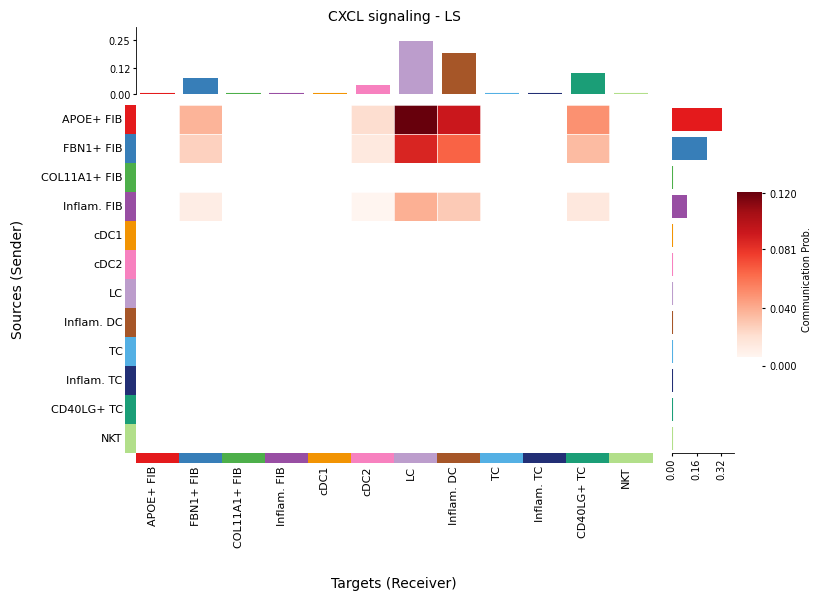

In [25]:
for name, obj in object_list.items():
    if pathway_show not in obj.pathway_network.get("prob", {}):
        continue
    fig = cc.plot_network_heatmap(
        obj, signaling=pathway_show, color_heatmap="Reds",
        title_name=f"{pathway_show} signaling - {name}", return_fig=True,
    )
    save_fig(fig, f"cmp_16b_heatmap_{pathway_show}_{name}.png")

## CXCL pathway - chord diagram per dataset


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16c_chord_CXCL_NL.png


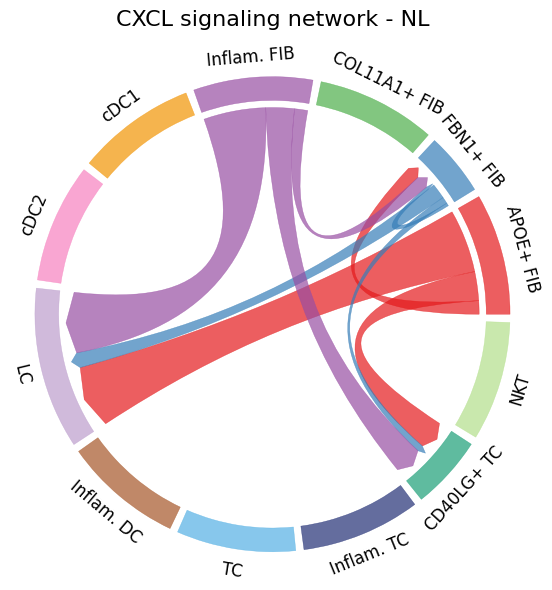

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_16c_chord_CXCL_LS.png


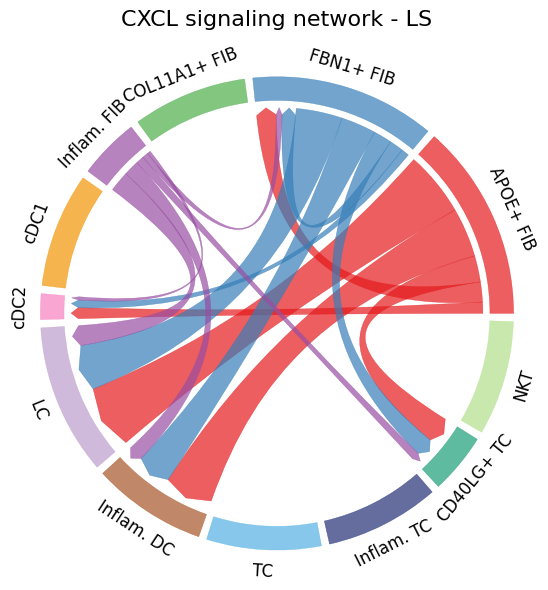

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_17a_chord_gene_received_InflamDC_TC_NL.png


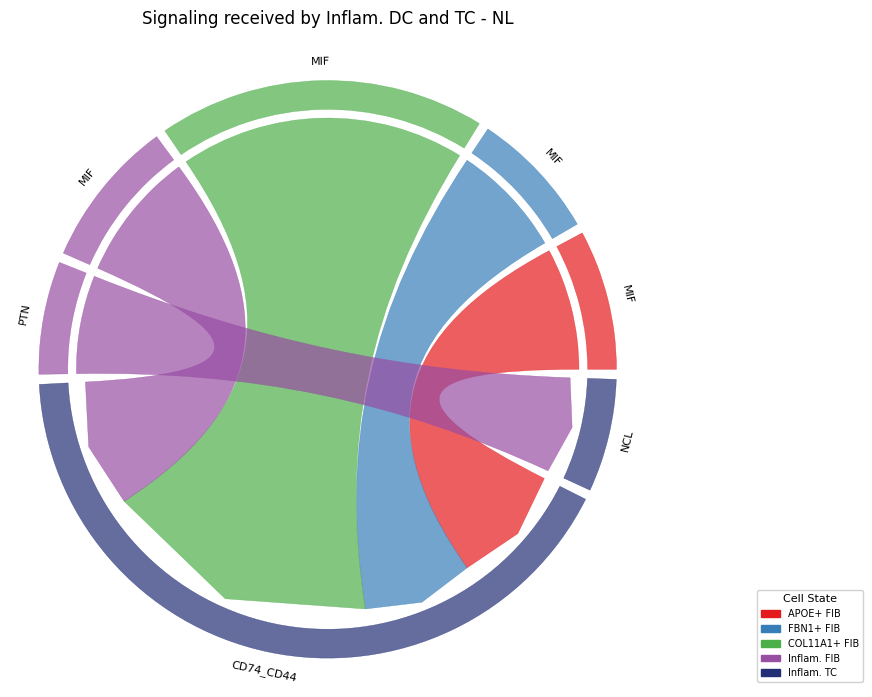

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_17a_chord_gene_received_InflamDC_TC_LS.png


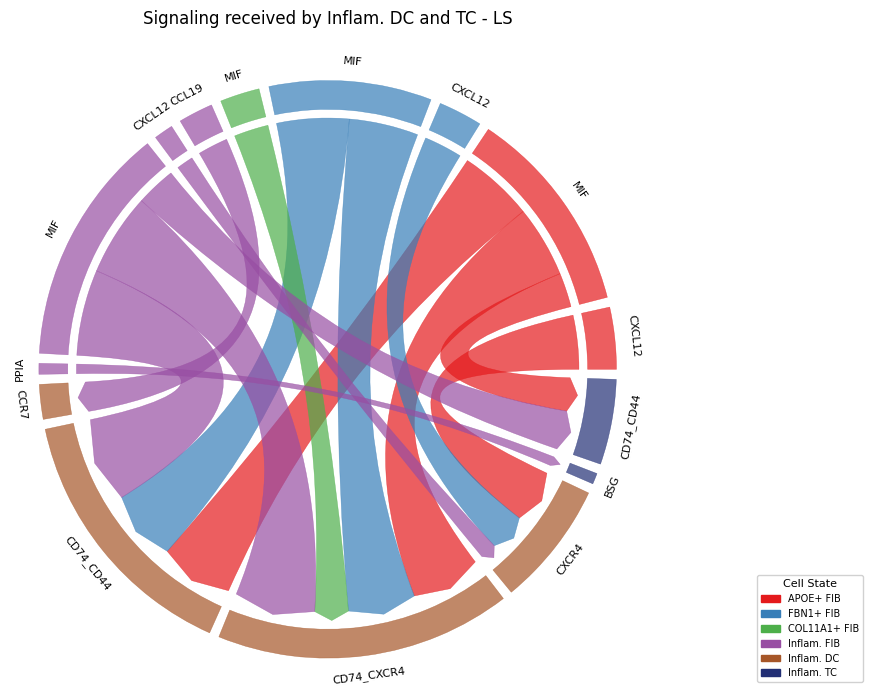

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_17b_chord_pathways_fibroblast_to_immune_NL.png


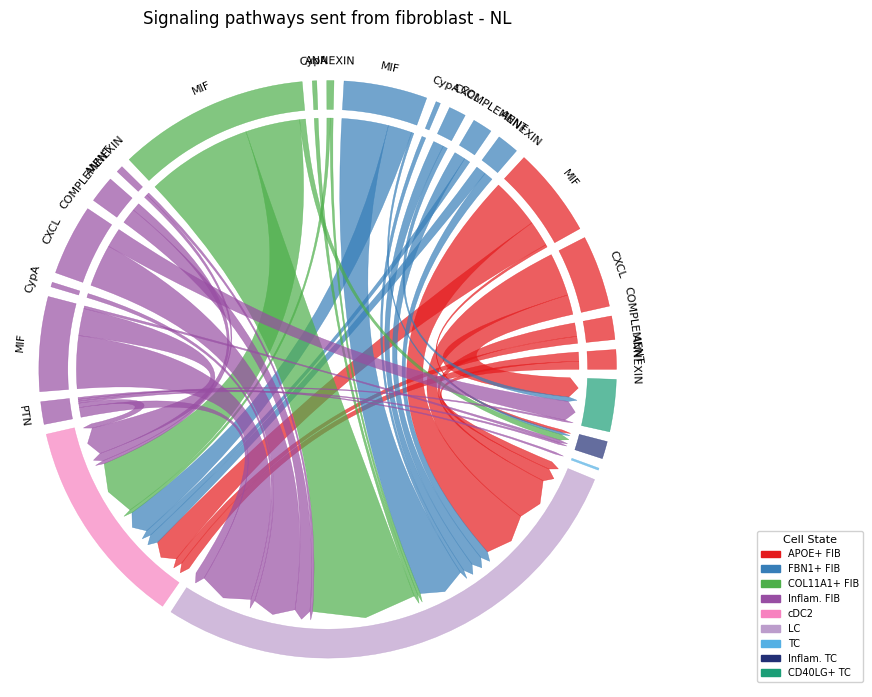

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_17b_chord_pathways_fibroblast_to_immune_LS.png


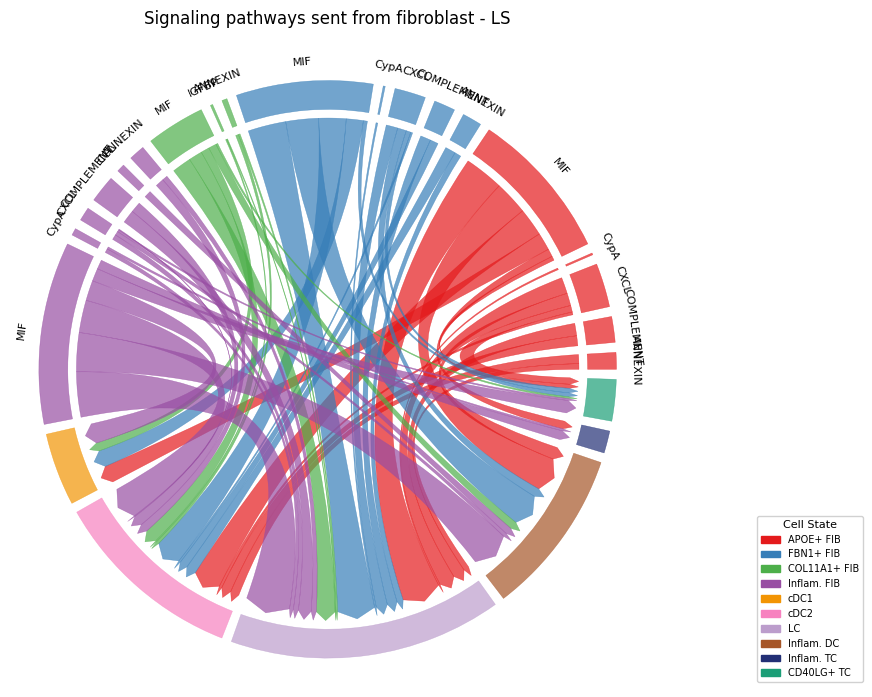

In [26]:
for name, obj in object_list.items():
    if pathway_show not in obj.pathway_network.get("prob", {}):
        continue
    fig = cc.plot_network_aggregate(
        obj, signaling=pathway_show, layout="chord",
        title_name=f"{pathway_show} signaling network - {name}", return_fig=True,
    )
    save_fig(fig, f"cmp_16c_chord_{pathway_show}_{name}.png")

fibroblast_sources = levels0[:4]
inflammatory_targets = [levels0[7], levels0[9]]
immune_targets = levels0[4:11]
for name, obj in object_list.items():
    fig = cc.plot_network_chord_gene(
        obj, sources_use=fibroblast_sources, targets_use=inflammatory_targets,
        slot_name="network",
        title_name=f"Signaling received by Inflam. DC and TC - {name}",
        return_fig=True,
    )
    save_fig(fig, f"cmp_17a_chord_gene_received_InflamDC_TC_{name}.png")

for name, obj in object_list.items():
    fig = cc.plot_network_chord_gene(
        obj, sources_use=fibroblast_sources, targets_use=immune_targets,
        slot_name="pathway_network",
        title_name=f"Signaling pathways sent from fibroblast - {name}",
        return_fig=True,
    )
    save_fig(fig, f"cmp_17b_chord_pathways_fibroblast_to_immune_{name}.png")

---
## Part V: Compare signaling gene expression between datasets

plotGeneExpression


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_comparison\cmp_18_gene_expression_CXCL_split.png


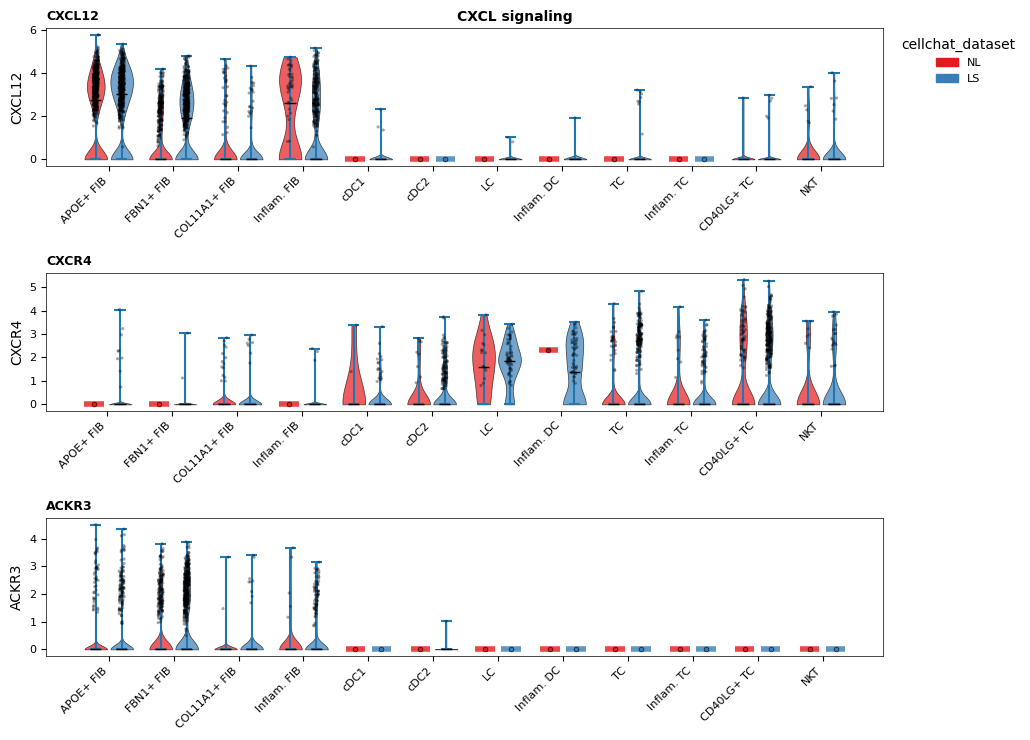

In [27]:
fig = cc.plot_gene_expression(
    cellchat_merged, signaling=pathway_show,
    split_by="cellchat_dataset", plot_type="violin", return_fig=True,
)
save_fig(fig, "cmp_18_gene_expression_CXCL_split.png")

---
## Save Results

In [28]:
output_pkl = project_root / "tutorial" / "cellchat_NL_LS_comparison.pkl"
with output_pkl.open("wb") as f:
    pickle.dump(
        {
            "cellchat_NL": cellchat_NL,
            "cellchat_LS": cellchat_LS,
            "cellchat_merged": cellchat_merged,
        },
        f,
    )
print(f"CellChatPy objects saved to: {output_pkl}")

for name, obj in object_list.items():
    df_net = cc.subset_communication(obj)
    csv_path = project_root / "tutorial" / f"cellchat_{name}_interactions.csv"
    df_net.to_csv(csv_path, index=False)
    print(f"{name}: {len(df_net)} interactions saved to {csv_path}")

elapsed_total = time.time() - ptm_total
print(f"Total elapsed: {elapsed_total:.1f} s ({elapsed_total / 60:.1f} min)")

CellChatPy objects saved to: E:\Jin\cellchat.python_new\tutorial\cellchat_NL_LS_comparison.pkl
NL: 191 interactions saved to E:\Jin\cellchat.python_new\tutorial\cellchat_NL_interactions.csv
LS: 367 interactions saved to E:\Jin\cellchat.python_new\tutorial\cellchat_LS_interactions.csv
Total elapsed: 585.7 s (9.8 min)
